# H&M Customer Analytics - Exploratory Data Analysis

In [ ]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import warnings
import os
from datetime import datetime, timedelta

# Suppress warnings
warnings.filterwarnings('ignore')

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.width', None)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ All packages imported successfully")
print("✓ Display and plotting options configured")


✓ All packages imported successfully
✓ Display and plotting options configured


## 1. Data Loading and Initial Overview

This section loads the cleaned datasets and provides an initial overview of the data structure, size, and basic characteristics.


In [ ]:
# STEP 1: LOAD DATA
print("="*80)
print("LOADING CLEANED DATA FILES")
print("="*80)

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set data path to Cleaned_Datasets folder in Google Drive
data_path = '/content/drive/MyDrive/Cleaned_Datasets'

# Check if path exists, if not, try alternative locations
if not os.path.exists(data_path):
    # Try alternative path in current directory
    alt_path = os.path.join(os.getcwd(), 'Cleaned_Datasets')
    if os.path.exists(alt_path):
        data_path = alt_path
        print(f"⚠ Using alternative path: {data_path}")
    else:
        print(f"⚠ Warning: Data path not found. Please update the path.")
        print(f"   Expected: {data_path}")

# Load data files
print("\nLoading data files...")
try:
    customers = pd.read_csv(os.path.join(data_path, 'customers_clean.csv'))
    print(f"✓ Customers loaded: {len(customers):,} records")
except FileNotFoundError:
    print("⚠ customers_clean.csv not found")
    customers = None

try:
    articles = pd.read_csv(os.path.join(data_path, 'articles_clean.csv'))
    print(f"✓ Articles loaded: {len(articles):,} records")
except FileNotFoundError:
    print("⚠ articles_clean.csv not found")
    articles = None

try:
    transactions = pd.read_csv(os.path.join(data_path, 'transactions_clean_df.csv'))
    print(f"✓ Transactions loaded: {len(transactions):,} records")

    # Convert date column if it exists
    if 't_dat' in transactions.columns:
        transactions['t_dat'] = pd.to_datetime(transactions['t_dat'], errors='coerce')
        transactions = transactions.dropna(subset=['t_dat'])
        print(f"✓ Date column converted: {transactions['t_dat'].min().date()} to {transactions['t_dat'].max().date()}")
except FileNotFoundError:
    print("⚠ transactions_clean_df.csv not found")
    transactions = None

print("\n" + "="*80)
print("DATA LOADING COMPLETE")
print("="*80)


LOADING CLEANED DATA FILES

Loading data files...
✓ Customers loaded: 1,371,980 records
✓ Articles loaded: 105,421 records
✓ Transactions loaded: 28,813,419 records
✓ Date column converted: 2018-09-20 to 2020-09-22

DATA LOADING COMPLETE


In [ ]:
# STEP 2: INITIAL DATA OVERVIEW
print("="*80)
print("INITIAL DATA OVERVIEW")
print("="*80)

# Create overview summary
overview_data = []

if customers is not None:
    overview_data.append({
        'Dataset': 'Customers',
        'Records': f"{len(customers):,}",
        'Columns': customers.shape[1],
        'Memory (MB)': f"{customers.memory_usage(deep=True).sum() / 1024**2:.2f}",
        'Date Range': 'N/A'
    })

if articles is not None:
    overview_data.append({
        'Dataset': 'Articles',
        'Records': f"{len(articles):,}",
        'Columns': articles.shape[1],
        'Memory (MB)': f"{articles.memory_usage(deep=True).sum() / 1024**2:.2f}",
        'Date Range': 'N/A'
    })

if transactions is not None:
    date_range = f"{transactions['t_dat'].min().date()} to {transactions['t_dat'].max().date()}"
    overview_data.append({
        'Dataset': 'Transactions',
        'Records': f"{len(transactions):,}",
        'Columns': transactions.shape[1],
        'Memory (MB)': f"{transactions.memory_usage(deep=True).sum() / 1024**2:.2f}",
        'Date Range': date_range
    })

overview_df = pd.DataFrame(overview_data)
display(overview_df)

# Display column information
print("\n" + "="*80)
print("DATASET STRUCTURE")
print("="*80)

if customers is not None:
    print("\n📊 CUSTOMERS DATASET:")
    print(f"   Shape: {customers.shape[0]:,} rows × {customers.shape[1]} columns")
    print(f"   Columns: {', '.join(customers.columns.tolist())}")
    print(f"\n   Data Types:")
    print(customers.dtypes)
    print(f"\n   Sample Data (first 5 rows):")
    display(customers.head())

if articles is not None:
    print("\n📦 ARTICLES DATASET:")
    print(f"   Shape: {articles.shape[0]:,} rows × {articles.shape[1]} columns")
    print(f"   Columns: {', '.join(articles.columns.tolist())}")
    print(f"\n   Data Types:")
    print(articles.dtypes)
    print(f"\n   Sample Data (first 5 rows):")
    display(articles.head())

if transactions is not None:
    print("\n💰 TRANSACTIONS DATASET:")
    print(f"   Shape: {transactions.shape[0]:,} rows × {transactions.shape[1]} columns")
    print(f"   Columns: {', '.join(transactions.columns.tolist())}")
    print(f"\n   Data Types:")
    print(transactions.dtypes)
    print(f"\n   Sample Data (first 5 rows):")
    display(transactions.head())


INITIAL DATA OVERVIEW


,Dataset,Records,Columns,Memory (MB),Date Range
0,Customers,"1,371,980",7,471.10,N/A
1,Articles,"105,421",25,106.12,N/A
2,Transactions,"28,813,419",5,3984.40,2018-09-20 to 2020-09-22



DATASET STRUCTURE

📊 CUSTOMERS DATASET:
   Shape: 1,371,980 rows × 7 columns
   Columns: customer_id, fn, active, club_member_status, fashion_news_frequency, age, postal_code

   Data Types:
customer_id                object
fn                          int64
active                      int64
club_member_status         object
fashion_news_frequency     object
age                       float64
postal_code                object
dtype: object

   Sample Data (first 5 rows):


,customer_id,fn,active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0,0,ACTIVE,NONE,49.000,52043EE2162CF5AA7EE79974281641C6F11A68D276429A...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,0,0,ACTIVE,NONE,25.000,2973ABC54DAA8A5F8CCFE9362140C63247C5EEE03F1D93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0,0,ACTIVE,NONE,24.000,64F17E6A330A85798E4998F62D0930D14DB8DB1C054AF6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,0,0,ACTIVE,NONE,54.000,5D36574F52495E81F019B680C843C443BD343D5CA5B1C2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1,1,ACTIVE,REGULARLY,52.000,25FA5DDEE9AAC01B35208D01736E57942317D756B32DDD...



📦 ARTICLES DATASET:
   Shape: 105,421 rows × 25 columns
   Columns: article_id, product_code, prod_name, product_type_no, product_type_name, product_group_name, graphical_appearance_no, graphical_appearance_name, colour_group_code, colour_group_name, perceived_colour_value_id, perceived_colour_value_name, perceived_colour_master_id, perceived_colour_master_name, department_no, department_name, index_code, index_name, index_group_no, index_group_name, section_no, section_name, garment_group_no, garment_group_name, detail_desc

   Data Types:
article_id                       int64
product_code                     int64
prod_name                       object
product_type_no                  int64
product_type_name               object
product_group_name              object
graphical_appearance_no          int64
graphical_appearance_name       object
colour_group_code                int64
colour_group_name               object
perceived_colour_value_id        int64
perceived_colour_value_

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,perceived_colour_value_id,perceived_colour_value_name,perceived_colour_master_id,perceived_colour_master_name,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,4,Dark,5,Black,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,3,Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top,253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,1,Dusty Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt,306,Bra,Underwear,1010016,Solid,9,Black,4,Dark,5,Black,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt,306,Bra,Underwear,1010016,Solid,10,White,3,Light,9,White,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."



💰 TRANSACTIONS DATASET:
   Shape: 28,813,419 rows × 5 columns
   Columns: t_dat, customer_id, article_id, price, sales_channel_id

   Data Types:
t_dat               datetime64[ns]
customer_id                 object
article_id                   int64
price                      float64
sales_channel_id             int64
dtype: object

   Sample Data (first 5 rows):


,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.051,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.017,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.017,2


In [ ]:
# STEP 3: DATA QUALITY CHECK
print("="*80)
print("DATA QUALITY ASSESSMENT")
print("="*80)

quality_summary = []

if customers is not None:
    missing = customers.isnull().sum()
    missing_pct = (missing / len(customers) * 100).round(2)
    quality_summary.append({
        'Dataset': 'Customers',
        'Total Records': len(customers),
        'Missing Values': missing.sum(),
        'Duplicate Records': customers.duplicated().sum(),
        'Unique Customers': customers['customer_id'].nunique() if 'customer_id' in customers.columns else 'N/A'
    })
    print("\n📊 CUSTOMERS - Missing Values:")
    missing_df = pd.DataFrame({
        'Column': missing.index,
        'Missing Count': missing.values,
        'Missing %': missing_pct.values
    })
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
    if len(missing_df) > 0:
        display(missing_df)
    else:
        print("   ✓ No missing values")

if articles is not None:
    missing = articles.isnull().sum()
    missing_pct = (missing / len(articles) * 100).round(2)
    quality_summary.append({
        'Dataset': 'Articles',
        'Total Records': len(articles),
        'Missing Values': missing.sum(),
        'Duplicate Records': articles.duplicated().sum(),
        'Unique Articles': articles['article_id'].nunique() if 'article_id' in articles.columns else 'N/A'
    })
    print("\n📦 ARTICLES - Missing Values:")
    missing_df = pd.DataFrame({
        'Column': missing.index,
        'Missing Count': missing.values,
        'Missing %': missing_pct.values
    })
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
    if len(missing_df) > 0:
        display(missing_df)
    else:
        print("   ✓ No missing values")

if transactions is not None:
    missing = transactions.isnull().sum()
    missing_pct = (missing / len(transactions) * 100).round(2)
    quality_summary.append({
        'Dataset': 'Transactions',
        'Total Records': len(transactions),
        'Missing Values': missing.sum(),
        'Duplicate Records': transactions.duplicated().sum(),
        'Unique Transactions': len(transactions)
    })
    print("\n💰 TRANSACTIONS - Missing Values:")
    missing_df = pd.DataFrame({
        'Column': missing.index,
        'Missing Count': missing.values,
        'Missing %': missing_pct.values
    })
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
    if len(missing_df) > 0:
        display(missing_df)
    else:
        print("   ✓ No missing values")

print("\n" + "="*80)
print("DATA QUALITY SUMMARY")
print("="*80)
quality_df = pd.DataFrame(quality_summary)
display(quality_df)


DATA QUALITY ASSESSMENT

📊 CUSTOMERS - Missing Values:
   ✓ No missing values

📦 ARTICLES - Missing Values:
   ✓ No missing values

💰 TRANSACTIONS - Missing Values:
   ✓ No missing values

DATA QUALITY SUMMARY


,Dataset,Total Records,Missing Values,Duplicate Records,Unique Customers,Unique Articles,Unique Transactions
0,Customers,1371980,0,0,1371980.000,NaN,NaN
1,Articles,105421,0,0,NaN,105421.000,NaN
2,Transactions,28813419,0,0,NaN,NaN,28813419.000


## 2. Customer Data Exploration

This section provides detailed analysis of customer demographics, membership status, and engagement patterns.


CUSTOMER DATA EXPLORATION

📊 CUSTOMER DEMOGRAPHICS AND SEGMENTATION
--------------------------------------------------------------------------------

Age Statistics:


,count,mean,std,min,25%,50%,75%,max
age,1371980.000,36.336,14.238,16.000,24.000,32.000,49.000,99.000


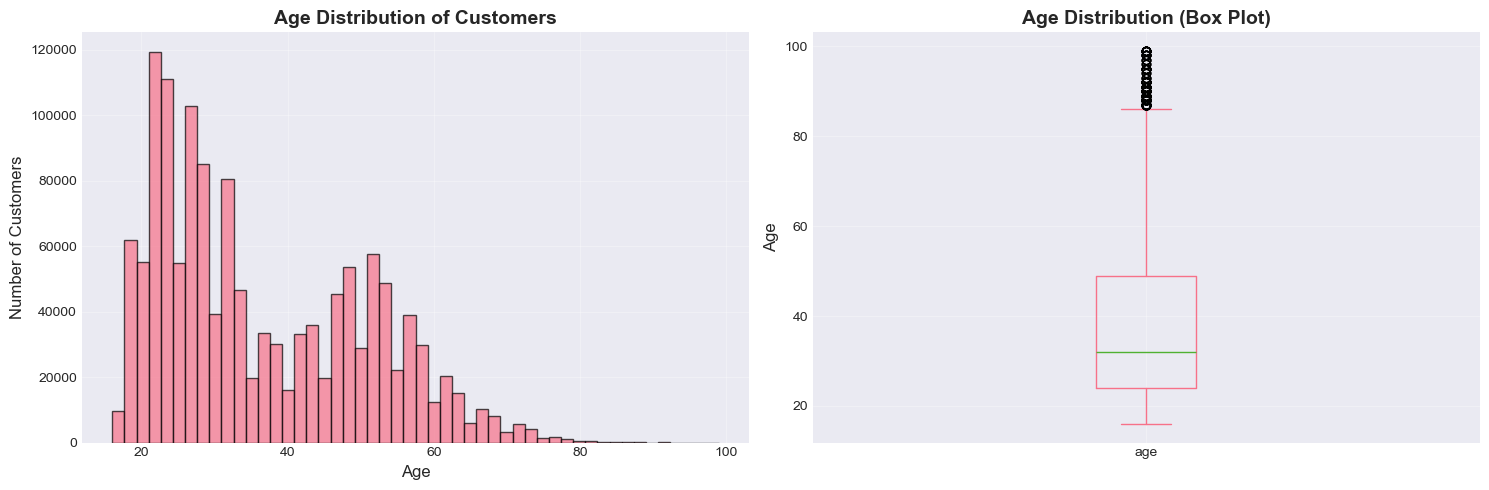


Age Categories:


,Count
age_category,
18-25,357169
26-35,409153
36-45,169041
46-55,253951
56-65,139064
65+,43602


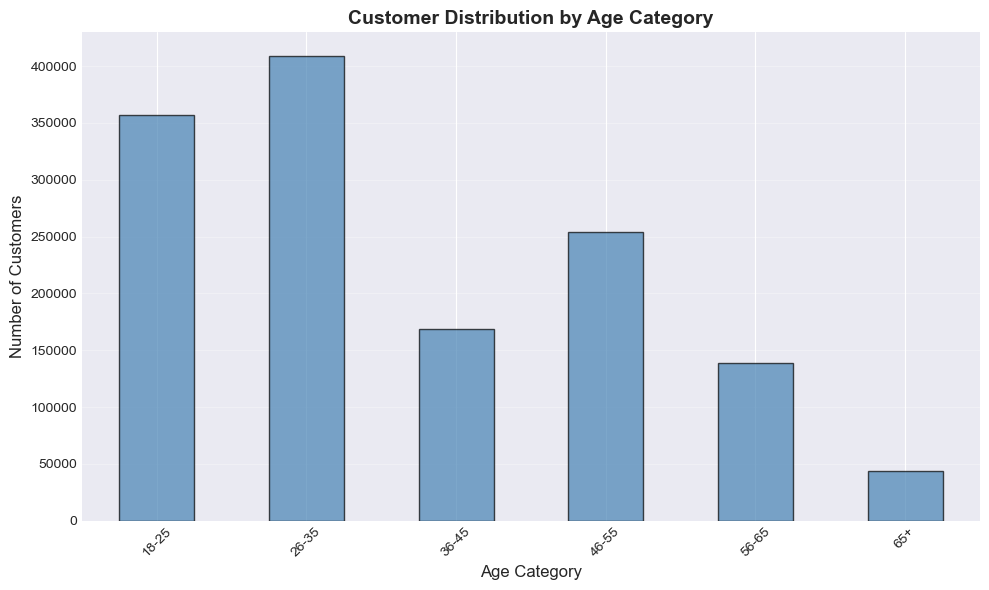


📊 CLUB MEMBERSHIP STATUS
--------------------------------------------------------------------------------


,Count,Percentage
club_member_status,,
ACTIVE,1272491,92.750
PRE-CREATE,92960,6.780
UNKNOWN,6062,0.440
LEFT CLUB,467,0.030


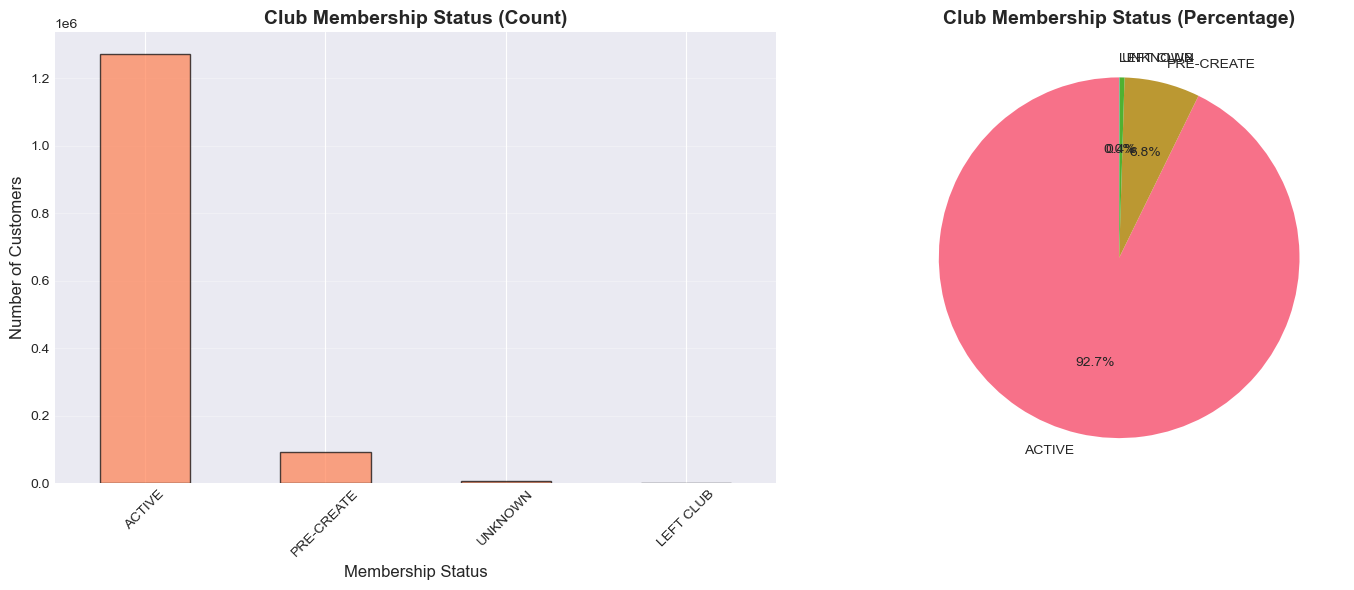


📊 FASHION NEWS FREQUENCY
--------------------------------------------------------------------------------


,Count,Percentage
fashion_news_frequency,,
NONE,877711,63.970
REGULARLY,477416,34.800
UNKNOWN,16011,1.170
MONTHLY,842,0.060


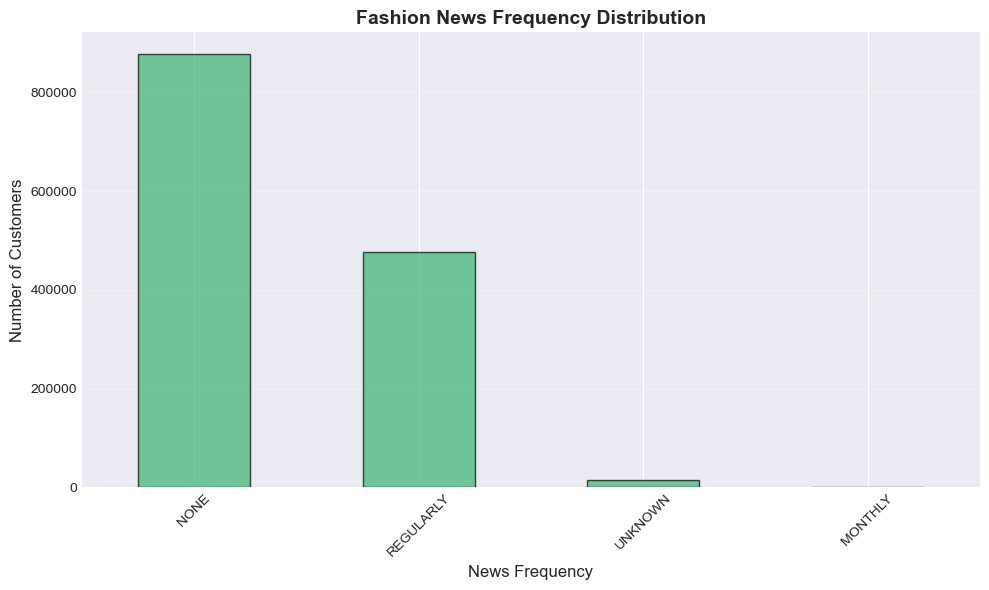


📊 ACTIVE STATUS
--------------------------------------------------------------------------------


,Count,Percentage
active,,
0,907576,66.150
1,464404,33.850


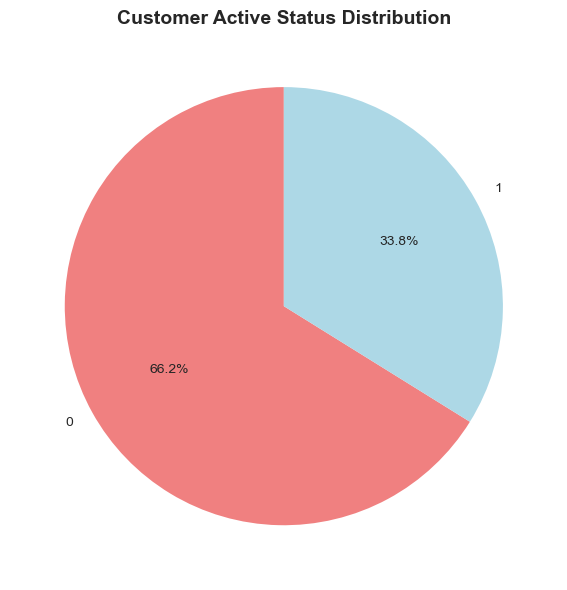


📊 FASHION NEWS SUBSCRIPTION (FN)
--------------------------------------------------------------------------------


,Count,Percentage
fn,,
0,895050,65.240
1,476930,34.760


In [ ]:
# CUSTOMER DATA EXPLORATION
if customers is not None:
    print("="*80)
    print("CUSTOMER DATA EXPLORATION")
    print("="*80)

    # Basic Statistics
    print("\n📊 CUSTOMER DEMOGRAPHICS AND SEGMENTATION")
    print("-" * 80)

    # Age distribution
    if 'age' in customers.columns:
        age_stats = customers['age'].describe()
        print("\nAge Statistics:")
        display(pd.DataFrame(age_stats).T)

        # Age distribution visualization
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # Histogram
        customers['age'].hist(bins=50, ax=axes[0], edgecolor='black', alpha=0.7)
        axes[0].set_title('Age Distribution of Customers', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Age', fontsize=12)
        axes[0].set_ylabel('Number of Customers', fontsize=12)
        axes[0].grid(True, alpha=0.3)

        # Box plot
        customers['age'].plot(kind='box', ax=axes[1], vert=True)
        axes[1].set_title('Age Distribution (Box Plot)', fontsize=14, fontweight='bold')
        axes[1].set_ylabel('Age', fontsize=12)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Age categories
        print("\nAge Categories:")
        age_bins = [0, 25, 35, 45, 55, 65, 100]
        age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
        customers['age_category'] = pd.cut(customers['age'], bins=age_bins, labels=age_labels, right=False)
        age_cat_counts = customers['age_category'].value_counts().sort_index()
        display(age_cat_counts.to_frame('Count'))

        # Visualization
        plt.figure(figsize=(10, 6))
        age_cat_counts.plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.7)
        plt.title('Customer Distribution by Age Category', fontsize=14, fontweight='bold')
        plt.xlabel('Age Category', fontsize=12)
        plt.ylabel('Number of Customers', fontsize=12)
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

    # Club membership status
    if 'club_member_status' in customers.columns:
        print("\n📊 CLUB MEMBERSHIP STATUS")
        print("-" * 80)
        club_status = customers['club_member_status'].value_counts()
        club_status_pct = customers['club_member_status'].value_counts(normalize=True) * 100

        club_df = pd.DataFrame({
            'Count': club_status,
            'Percentage': club_status_pct.round(2)
        })
        display(club_df)

        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        club_status.plot(kind='bar', ax=axes[0], color='coral', edgecolor='black', alpha=0.7)
        axes[0].set_title('Club Membership Status (Count)', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Membership Status', fontsize=12)
        axes[0].set_ylabel('Number of Customers', fontsize=12)
        axes[0].tick_params(axis='x', rotation=45)
        axes[0].grid(True, alpha=0.3, axis='y')

        club_status_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
        axes[1].set_title('Club Membership Status (Percentage)', fontsize=14, fontweight='bold')
        axes[1].set_ylabel('')

        plt.tight_layout()
        plt.show()

    # Fashion news frequency
    if 'fashion_news_frequency' in customers.columns:
        print("\n📊 FASHION NEWS FREQUENCY")
        print("-" * 80)
        news_freq = customers['fashion_news_frequency'].value_counts()
        news_freq_pct = customers['fashion_news_frequency'].value_counts(normalize=True) * 100

        news_df = pd.DataFrame({
            'Count': news_freq,
            'Percentage': news_freq_pct.round(2)
        })
        display(news_df)

        # Visualization
        plt.figure(figsize=(10, 6))
        news_freq.plot(kind='bar', color='mediumseagreen', edgecolor='black', alpha=0.7)
        plt.title('Fashion News Frequency Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('News Frequency', fontsize=12)
        plt.ylabel('Number of Customers', fontsize=12)
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

    # Active status
    if 'active' in customers.columns:
        print("\n📊 ACTIVE STATUS")
        print("-" * 80)
        active_status = customers['active'].value_counts()
        active_status_pct = customers['active'].value_counts(normalize=True) * 100

        active_df = pd.DataFrame({
            'Count': active_status,
            'Percentage': active_status_pct.round(2)
        })
        display(active_df)

        # Visualization
        plt.figure(figsize=(8, 6))
        active_status.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightblue'])
        plt.title('Customer Active Status Distribution', fontsize=14, fontweight='bold')
        plt.ylabel('')
        plt.tight_layout()
        plt.show()

    # FN (Fashion News) subscription
    if 'fn' in customers.columns:
        print("\n📊 FASHION NEWS SUBSCRIPTION (FN)")
        print("-" * 80)
        fn_status = customers['fn'].value_counts()
        fn_status_pct = customers['fn'].value_counts(normalize=True) * 100

        fn_df = pd.DataFrame({
            'Count': fn_status,
            'Percentage': fn_status_pct.round(2)
        })
        display(fn_df)
else:
    print("⚠ Customer data not available")


CUSTOMER DEMOGRAPHICS SEGMENTATION

📊 AGE-BASED SEGMENTATION
--------------------------------------------------------------------------------


,Count,Percentage
age_segment,,
Young (18-25),357169,26.030
Young Adult (26-35),409153,29.820
Adult (36-45),169041,12.320
Middle-Aged (46-55),253951,18.510
Senior (56-65),139064,10.140
Elderly (65+),43602,3.180


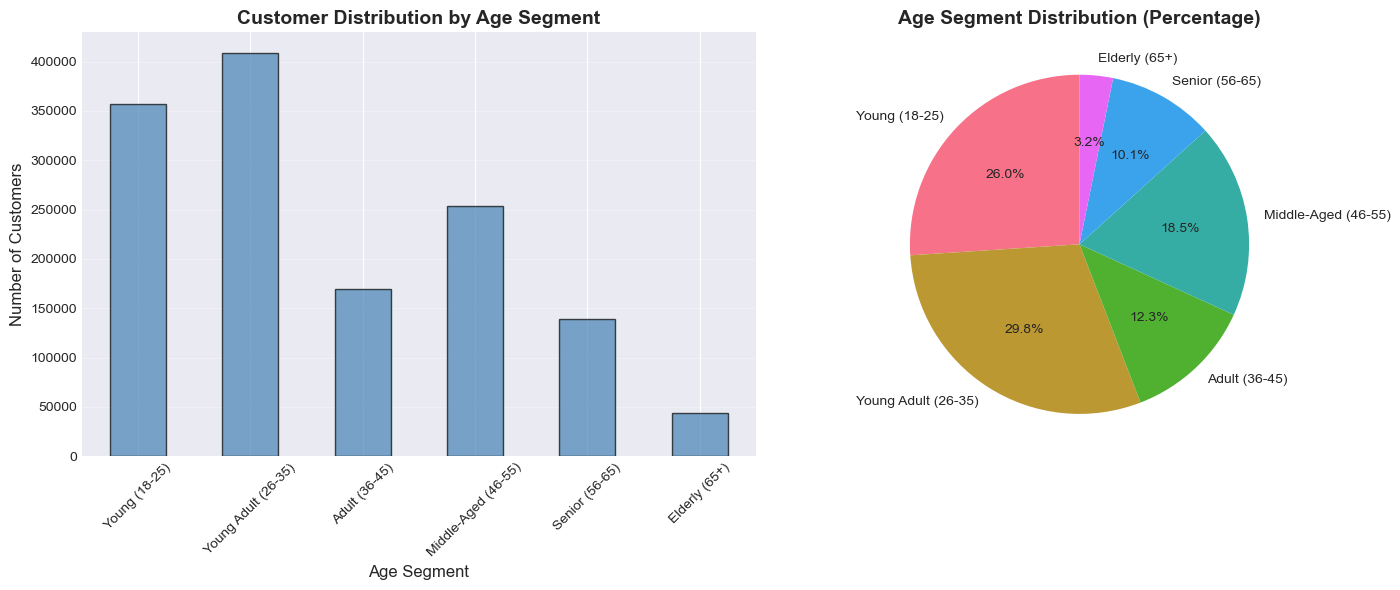


📊 MULTI-DIMENSIONAL DEMOGRAPHIC SEGMENTATION
--------------------------------------------------------------------------------

Age Segment × Club Membership Status:


club_member_status,ACTIVE,LEFT CLUB,PRE-CREATE,UNKNOWN
age_segment,,,,
Young (18-25),345230,147,11007,785
Young Adult (26-35),375650,147,30144,3212
Adult (36-45),153278,57,14965,741
Middle-Aged (46-55),231296,66,21771,818
Senior (56-65),127113,38,11531,382
Elderly (65+),39924,12,3542,124


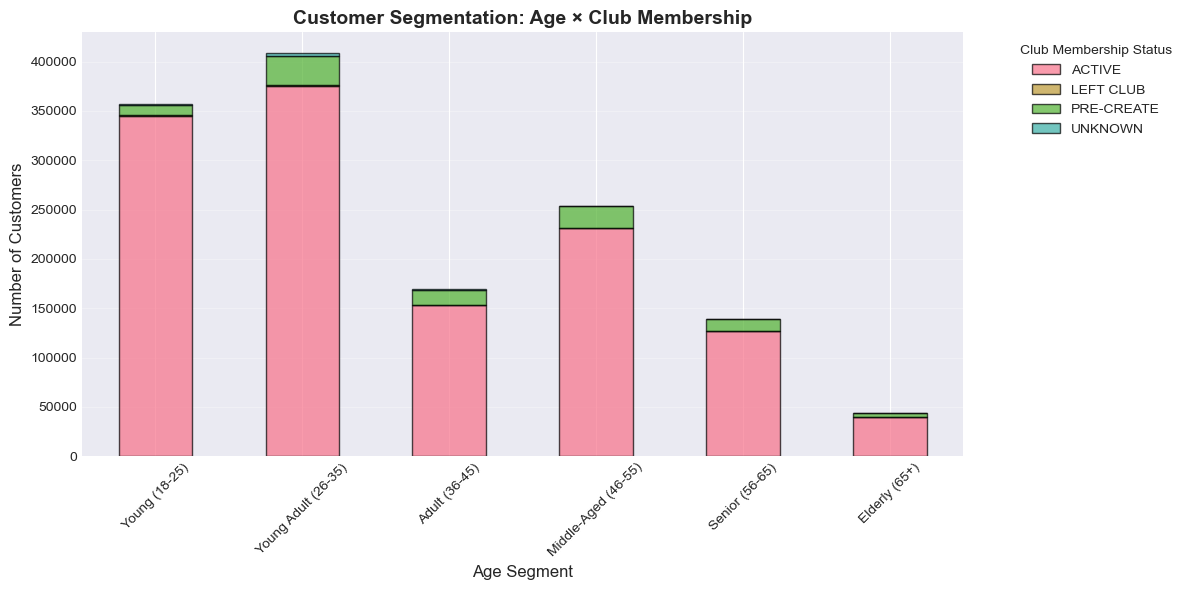


📊 FASHION NEWS ENGAGEMENT SEGMENTATION
--------------------------------------------------------------------------------


,Count,Percentage
engagement_segment,,
Low Engagement,877711,64.730
High Engagement,477416,35.210
Medium Engagement,842,0.060


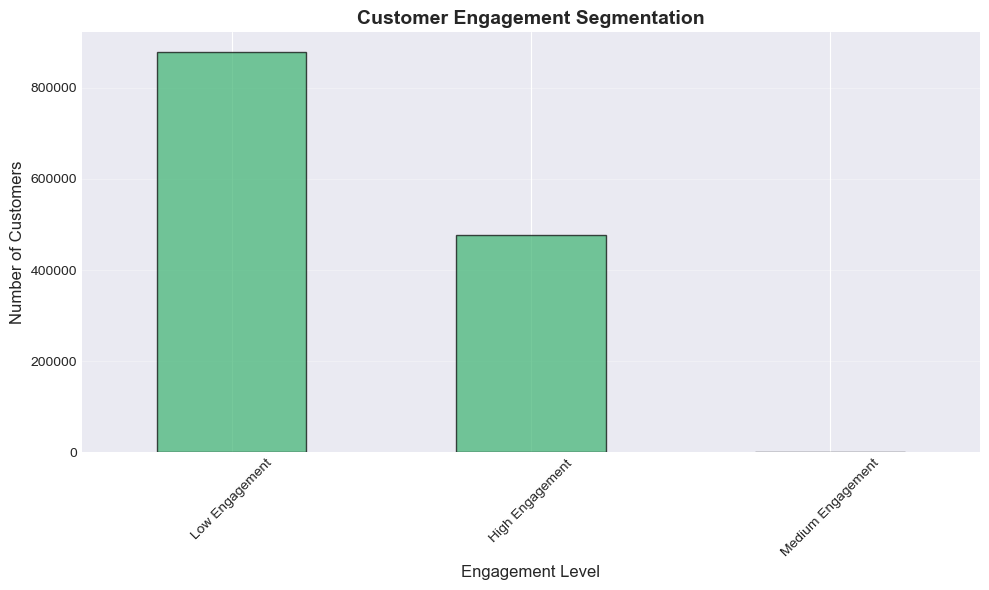

In [ ]:
# CUSTOMER DEMOGRAPHICS SEGMENTATION
if customers is not None:
    print("="*80)
    print("CUSTOMER DEMOGRAPHICS SEGMENTATION")
    print("="*80)

    # Create demographic segments
    if 'age' in customers.columns:
        # Age-based segmentation
        customers['age_segment'] = pd.cut(
            customers['age'],
            bins=[0, 25, 35, 45, 55, 65, 100],
            labels=['Young (18-25)', 'Young Adult (26-35)', 'Adult (36-45)', 'Middle-Aged (46-55)', 'Senior (56-65)', 'Elderly (65+)'],
            right=False
        )

        print("\n📊 AGE-BASED SEGMENTATION")
        print("-" * 80)
        age_seg_counts = customers['age_segment'].value_counts().sort_index()
        age_seg_pct = customers['age_segment'].value_counts(normalize=True).sort_index() * 100

        age_seg_df = pd.DataFrame({
            'Count': age_seg_counts,
            'Percentage': age_seg_pct.round(2)
        })
        display(age_seg_df)

        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        age_seg_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black', alpha=0.7)
        axes[0].set_title('Customer Distribution by Age Segment', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Age Segment', fontsize=12)
        axes[0].set_ylabel('Number of Customers', fontsize=12)
        axes[0].tick_params(axis='x', rotation=45)
        axes[0].grid(True, alpha=0.3, axis='y')

        age_seg_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
        axes[1].set_title('Age Segment Distribution (Percentage)', fontsize=14, fontweight='bold')
        axes[1].set_ylabel('')

        plt.tight_layout()
        plt.show()

    # Multi-dimensional segmentation
    if 'age' in customers.columns and 'club_member_status' in customers.columns:
        print("\n📊 MULTI-DIMENSIONAL DEMOGRAPHIC SEGMENTATION")
        print("-" * 80)

        # Age x Club Membership segmentation
        demo_seg = customers.groupby(['age_segment', 'club_member_status']).size().unstack(fill_value=0)
        print("\nAge Segment × Club Membership Status:")
        display(demo_seg)

        # Visualization
        demo_seg.plot(kind='bar', stacked=True, figsize=(12, 6), edgecolor='black', alpha=0.7)
        plt.title('Customer Segmentation: Age × Club Membership', fontsize=14, fontweight='bold')
        plt.xlabel('Age Segment', fontsize=12)
        plt.ylabel('Number of Customers', fontsize=12)
        plt.xticks(rotation=45)
        plt.legend(title='Club Membership Status', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

    # Fashion News Engagement Segmentation
    if 'fashion_news_frequency' in customers.columns:
        print("\n📊 FASHION NEWS ENGAGEMENT SEGMENTATION")
        print("-" * 80)

        # Create engagement segments
        customers['engagement_segment'] = customers['fashion_news_frequency'].map({
            'REGULARLY': 'High Engagement',
            'MONTHLY': 'Medium Engagement',
            'NONE': 'Low Engagement'
        })

        eng_seg_counts = customers['engagement_segment'].value_counts()
        eng_seg_pct = customers['engagement_segment'].value_counts(normalize=True) * 100

        eng_seg_df = pd.DataFrame({
            'Count': eng_seg_counts,
            'Percentage': eng_seg_pct.round(2)
        })
        display(eng_seg_df)

        # Visualization
        plt.figure(figsize=(10, 6))
        eng_seg_counts.plot(kind='bar', color='mediumseagreen', edgecolor='black', alpha=0.7)
        plt.title('Customer Engagement Segmentation', fontsize=14, fontweight='bold')
        plt.xlabel('Engagement Level', fontsize=12)
        plt.ylabel('Number of Customers', fontsize=12)
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()
else:
    print("⚠ Customer data not available")


## 2b. Customer Behavior Insights and Segmentation

This section analyzes customer behavior patterns and creates behavior-based segments.


CUSTOMER BEHAVIOR INSIGHTS AND SEGMENTATION

📊 CUSTOMER BEHAVIOR METRICS
--------------------------------------------------------------------------------

Customer Behavior Statistics:


,purchase_frequency,total_spent,avg_transaction_value,first_purchase,last_purchase,days_since_last_purchase,customer_tenure_days
count,1362281.000,1362281.000,1362281.000,1362281,1362281,1362281.000,1362281.000
mean,21.151,0.586,0.029,2019-05-02 11:03:35.778389760,2020-01-30 20:26:15.037162240,235.148,273.391
min,1.000,0.001,0.001,2018-09-20 00:00:00,2018-09-20 00:00:00,0.000,0.000
25%,3.000,0.083,0.021,2018-10-29 00:00:00,2019-08-21 00:00:00,48.000,0.000
50%,9.000,0.226,0.026,2019-02-16 00:00:00,2020-04-24 00:00:00,151.000,206.000
75%,25.000,0.645,0.033,2019-10-03 00:00:00,2020-08-05 00:00:00,398.000,549.000
max,1641.000,49.361,0.507,2020-09-22 00:00:00,2020-09-22 00:00:00,733.000,733.000
std,34.590,1.048,0.014,NaN,NaN,221.119,269.962



📊 PURCHASE FREQUENCY SEGMENTATION
--------------------------------------------------------------------------------


,Count,Percentage
frequency_segment,,
Low Frequency,380275,27.910
Medium-Low Frequency,335539,24.630
Medium-High Frequency,316289,23.220
High Frequency,330178,24.240


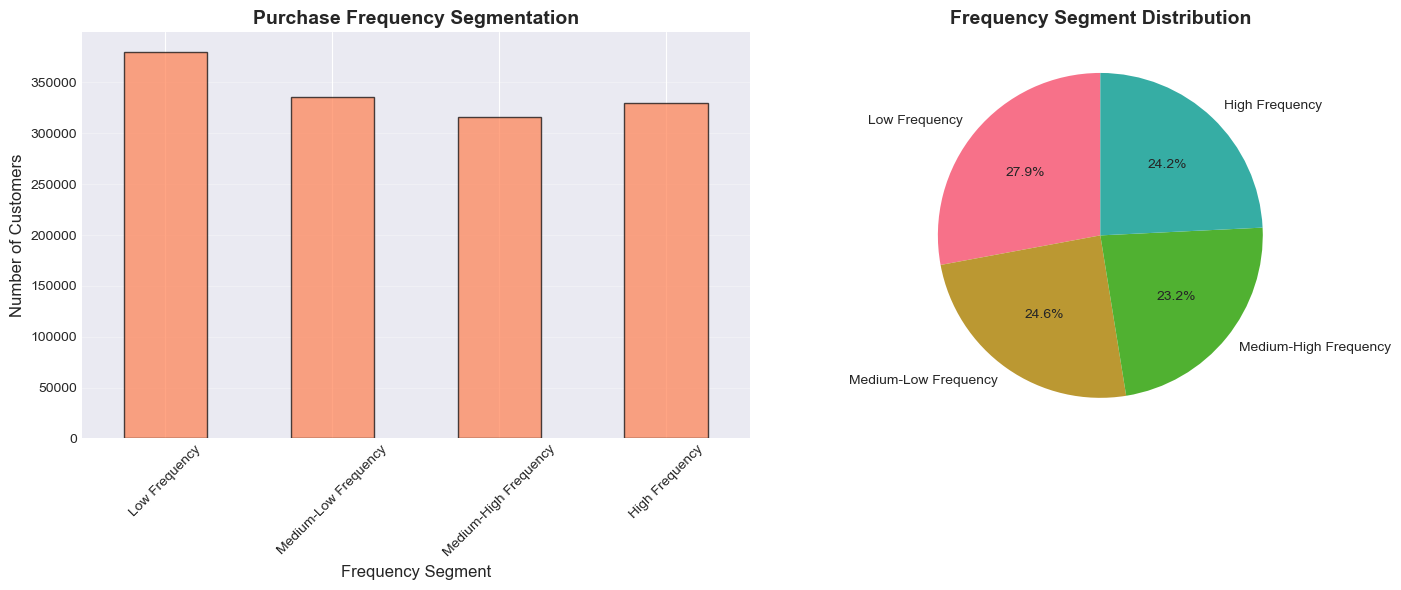


📊 SPENDING BEHAVIOR SEGMENTATION
--------------------------------------------------------------------------------


,Count,Percentage
spending_segment,,
Low Spender,340621,25.000
Medium-Low Spender,340520,25.000
Medium-High Spender,340570,25.000
High Spender,340570,25.000


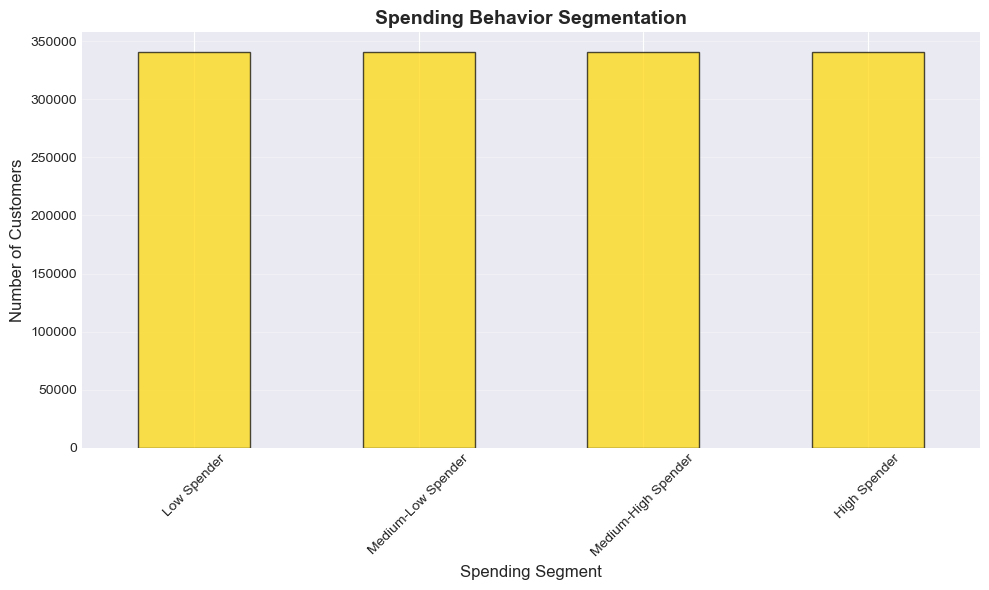


📊 RECENCY SEGMENTATION
--------------------------------------------------------------------------------


,Count,Percentage
recency_segment,,
Very Recent (0-30 days),240091,17.760
Recent (31-90 days),274456,20.300
Moderate (91-180 days),217356,16.080
Old (181-365 days),251889,18.630
Very Old (365+ days),367961,27.220


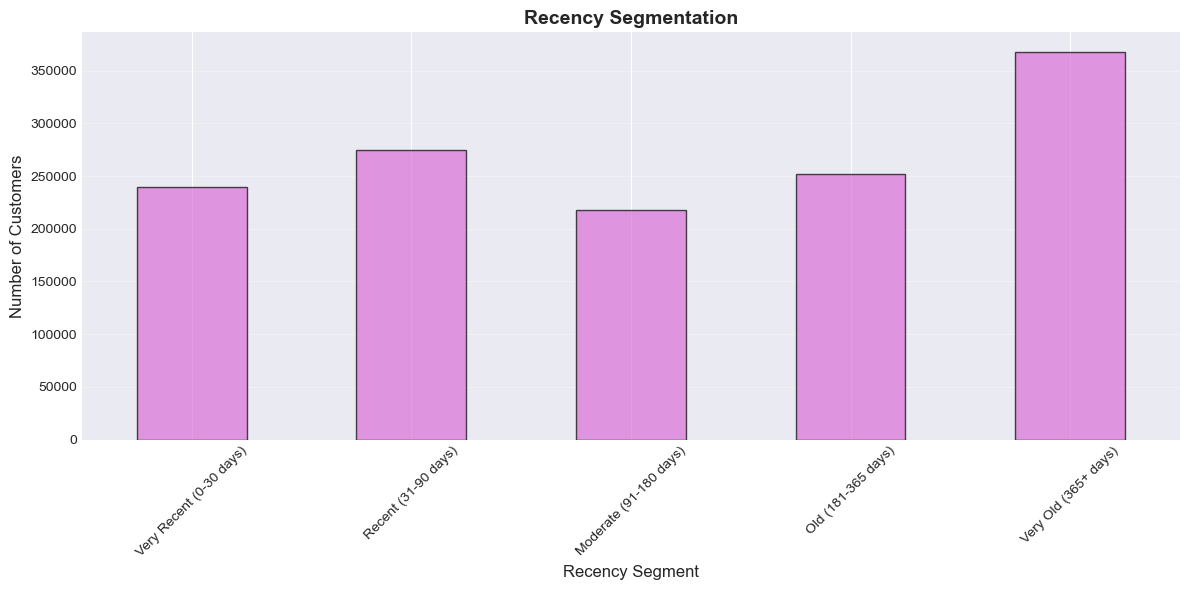


📊 COMBINED BEHAVIOR SEGMENTATION (RFM-STYLE)
--------------------------------------------------------------------------------

Top 10 Behavior Segment Combinations:


,Count
behavior_segment,
Low Frequency / Low Spender / Very Old (365+ days),150063
High Frequency / High Spender / Very Recent (0-30 days),126524
High Frequency / High Spender / Recent (31-90 days),99157
Medium-Low Frequency / Medium-Low Spender / Very Old (365+ days),84573
Low Frequency / Low Spender / Old (181-365 days),67112
Medium-High Frequency / Medium-High Spender / Recent (31-90 days),66315
Medium-Low Frequency / Medium-Low Spender / Old (181-365 days),49473
Medium-High Frequency / Medium-High Spender / Moderate (91-180 days),49274
Medium-High Frequency / Medium-High Spender / Old (181-365 days),49100



CUSTOMER BEHAVIOR ANALYSIS COMPLETE


In [ ]:
# CUSTOMER BEHAVIOR INSIGHTS AND SEGMENTATION
if transactions is not None and customers is not None:
    print("="*80)
    print("CUSTOMER BEHAVIOR INSIGHTS AND SEGMENTATION")
    print("="*80)

    # Calculate customer behavior metrics
    print("\n📊 CUSTOMER BEHAVIOR METRICS")
    print("-" * 80)

    # Customer transaction behavior
    customer_behavior = transactions.groupby('customer_id').agg({
        'article_id': 'count',  # Frequency
        'price': ['sum', 'mean'],  # Monetary value
        't_dat': ['min', 'max']  # First and last purchase
    }).reset_index()

    customer_behavior.columns = ['customer_id', 'purchase_frequency', 'total_spent', 'avg_transaction_value', 'first_purchase', 'last_purchase']

    # Calculate recency (days since last purchase)
    reference_date = transactions['t_dat'].max()
    customer_behavior['days_since_last_purchase'] = (reference_date - customer_behavior['last_purchase']).dt.days
    customer_behavior['customer_tenure_days'] = (customer_behavior['last_purchase'] - customer_behavior['first_purchase']).dt.days

    print("\nCustomer Behavior Statistics:")
    display(customer_behavior.describe())

    # Behavior-based segmentation: Frequency
    print("\n📊 PURCHASE FREQUENCY SEGMENTATION")
    print("-" * 80)

    # Create frequency segments using quartiles
    freq_quartiles = customer_behavior['purchase_frequency'].quantile([0.25, 0.5, 0.75])
    customer_behavior['frequency_segment'] = pd.cut(
        customer_behavior['purchase_frequency'],
        bins=[0, freq_quartiles[0.25], freq_quartiles[0.5], freq_quartiles[0.75], float('inf')],
        labels=['Low Frequency', 'Medium-Low Frequency', 'Medium-High Frequency', 'High Frequency']
    )

    freq_seg_counts = customer_behavior['frequency_segment'].value_counts().sort_index()
    freq_seg_pct = customer_behavior['frequency_segment'].value_counts(normalize=True).sort_index() * 100

    freq_seg_df = pd.DataFrame({
        'Count': freq_seg_counts,
        'Percentage': freq_seg_pct.round(2)
    })
    display(freq_seg_df)

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    freq_seg_counts.plot(kind='bar', ax=axes[0], color='coral', edgecolor='black', alpha=0.7)
    axes[0].set_title('Purchase Frequency Segmentation', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Frequency Segment', fontsize=12)
    axes[0].set_ylabel('Number of Customers', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, axis='y')

    freq_seg_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Frequency Segment Distribution', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

    # Behavior-based segmentation: Monetary Value
    print("\n📊 SPENDING BEHAVIOR SEGMENTATION")
    print("-" * 80)

    # Create spending segments using quartiles
    spend_quartiles = customer_behavior['total_spent'].quantile([0.25, 0.5, 0.75])
    customer_behavior['spending_segment'] = pd.cut(
        customer_behavior['total_spent'],
        bins=[0, spend_quartiles[0.25], spend_quartiles[0.5], spend_quartiles[0.75], float('inf')],
        labels=['Low Spender', 'Medium-Low Spender', 'Medium-High Spender', 'High Spender']
    )

    spend_seg_counts = customer_behavior['spending_segment'].value_counts().sort_index()
    spend_seg_pct = customer_behavior['spending_segment'].value_counts(normalize=True).sort_index() * 100

    spend_seg_df = pd.DataFrame({
        'Count': spend_seg_counts,
        'Percentage': spend_seg_pct.round(2)
    })
    display(spend_seg_df)

    # Visualization
    plt.figure(figsize=(10, 6))
    spend_seg_counts.plot(kind='bar', color='gold', edgecolor='black', alpha=0.7)
    plt.title('Spending Behavior Segmentation', fontsize=14, fontweight='bold')
    plt.xlabel('Spending Segment', fontsize=12)
    plt.ylabel('Number of Customers', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    # Behavior-based segmentation: Recency
    print("\n📊 RECENCY SEGMENTATION")
    print("-" * 80)

    # Create recency segments
    customer_behavior['recency_segment'] = pd.cut(
        customer_behavior['days_since_last_purchase'],
        bins=[0, 30, 90, 180, 365, float('inf')],
        labels=['Very Recent (0-30 days)', 'Recent (31-90 days)', 'Moderate (91-180 days)', 'Old (181-365 days)', 'Very Old (365+ days)']
    )

    recency_seg_counts = customer_behavior['recency_segment'].value_counts().sort_index()
    recency_seg_pct = customer_behavior['recency_segment'].value_counts(normalize=True).sort_index() * 100

    recency_seg_df = pd.DataFrame({
        'Count': recency_seg_counts,
        'Percentage': recency_seg_pct.round(2)
    })
    display(recency_seg_df)

    # Visualization
    plt.figure(figsize=(12, 6))
    recency_seg_counts.plot(kind='bar', color='orchid', edgecolor='black', alpha=0.7)
    plt.title('Recency Segmentation', fontsize=14, fontweight='bold')
    plt.xlabel('Recency Segment', fontsize=12)
    plt.ylabel('Number of Customers', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    # Combined Behavior Segmentation (RFM-like)
    print("\n📊 COMBINED BEHAVIOR SEGMENTATION (RFM-STYLE)")
    print("-" * 80)

    # Create combined segments
    customer_behavior['behavior_segment'] = customer_behavior.apply(
        lambda x: f"{x['frequency_segment']} / {x['spending_segment']} / {x['recency_segment']}",
        axis=1
    )

    # Top behavior combinations
    top_behavior_segments = customer_behavior['behavior_segment'].value_counts().head(10)
    print("\nTop 10 Behavior Segment Combinations:")
    display(top_behavior_segments.to_frame('Count'))

    # Store for later use
    customer_behavior_df = customer_behavior.copy()

    print("\n" + "="*80)
    print("CUSTOMER BEHAVIOR ANALYSIS COMPLETE")
    print("="*80)
else:
    print("⚠ Cannot perform behavior analysis - missing required datasets")


## 3. Articles/Product Data Exploration

This section analyzes product characteristics, categories, colors, and other product attributes.


## 3b. Product Performance Analysis

This section analyzes product performance metrics including sales volume, revenue, and popularity.


PRODUCT PERFORMANCE ANALYSIS

📊 PRODUCT PERFORMANCE METRICS
--------------------------------------------------------------------------------

Product Performance Statistics:


,total_purchases,total_revenue,avg_price
count,104547.000,104547.000,104547.000
mean,275.603,7.642,0.029
std,696.877,19.292,0.026
min,1.000,0.000,0.000
25%,13.000,0.238,0.014
50%,60.000,1.372,0.023
75%,262.000,7.205,0.034
max,42672.000,1382.012,0.507



📊 PRODUCT PERFORMANCE SEGMENTATION
--------------------------------------------------------------------------------

Product Sales Volume Segmentation:


,Product Count
sales_volume_segment,
Low Volume,27072
Medium-Low Volume,25435
Medium-High Volume,25925
High Volume,26115



Product Revenue Segmentation:


...

,article_id,prod_name,department_name,total_purchases,total_revenue
53832,706016001,Jade HW Skinny Denim TRS,Trousers,42672,1382.012
53833,706016002,Jade HW Skinny Denim TRS,Trousers,30862,999.628
1711,372860001,7p Basic Shaftless,Shopbasket Socks,29337,380.229
24808,610776002,Tilly,Jersey Basic,25234,203.809
70124,759871002,Tilda tank,EQ Divided Basics,23799,133.454
1712,372860002,7p Basic Shaftless,Shopbasket Socks,22472,273.766
3706,464297007,Greta Thong Mynta Low 3p,Casual Lingerie,21782,352.262
2233,399223001,Curvy Jeggings HW Ankle,Denim Trousers,19604,607.259
58427,720125001,SUPREME RW tights,Ladies Sport Bottoms,18975,615.029
24807,610776001,Tilly,Jersey Basic,18777,151.493



Top 10 Products by Revenue:


,article_id,prod_name,department_name,total_purchases,total_revenue
53832,706016001,Jade HW Skinny Denim TRS,Trousers,42672,1382.012
53833,706016002,Jade HW Skinny Denim TRS,Trousers,30862,999.628
15980,568601006,Mariette Blazer,Suit,16825,814.209
3087,448509014,Perrie Slim Mom Denim TRS,Trousers,16087,651.940
58427,720125001,SUPREME RW tights,Ladies Sport Bottoms,18975,615.029
2233,399223001,Curvy Jeggings HW Ankle,Denim Trousers,19604,607.259
53834,706016003,Jade HW Skinny Denim TRS,Trousers,18638,606.382
14232,562245046,Luna skinny RW,Trouser,17992,569.207
67435,751471001,Pluto RW slacks,Trouser,15803,510.226
39502,661794001,Flamingo,Outwear,4003,488.091



📊 DEPARTMENT PERFORMANCE ANALYSIS
--------------------------------------------------------------------------------

Top 15 Departments by Revenue:


,department,product_count,total_purchases,total_revenue,avg_price
208,Trouser,2636,1548971,53422.896,0.039
124,Knitwear,3434,1502706,52373.031,0.042
195,Swimwear,2075,2128005,47027.010,0.021
54,Dress,2065,1008274,40748.589,0.046
33,Blouse,2341,1518230,39058.746,0.026
81,Jersey,4560,1390422,38611.859,0.029
151,Outwear,991,348026,28465.969,0.081
46,Denim Trousers,489,579885,25621.926,0.046
210,Trousers,799,715590,22450.625,0.029
87,Jersey fancy,1390,1078516,21707.218,0.022


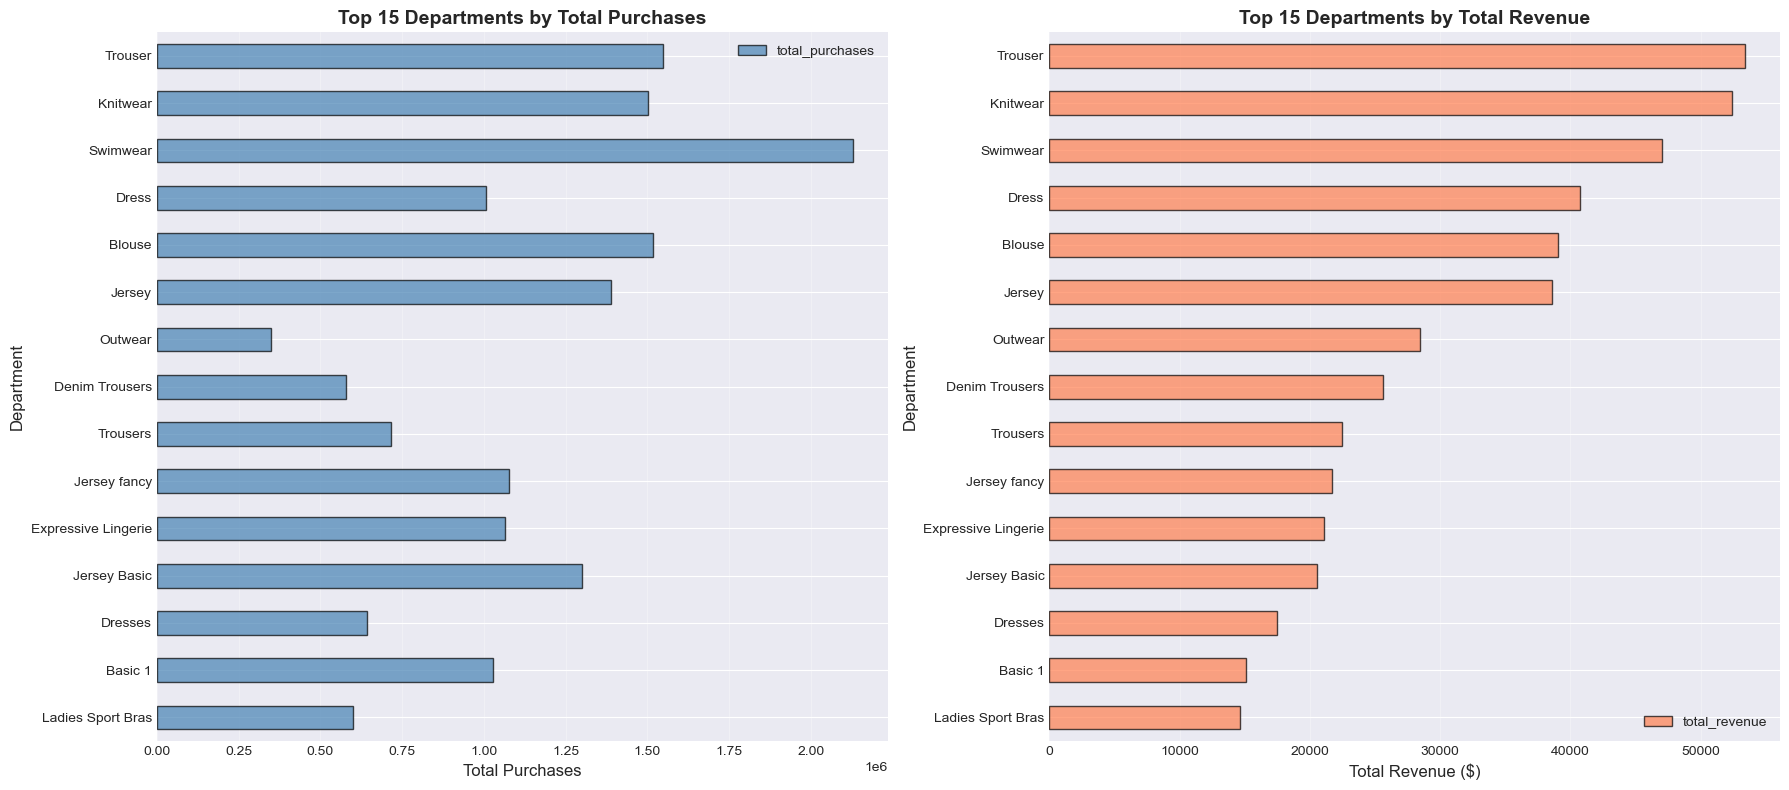


PRODUCT PERFORMANCE ANALYSIS COMPLETE


In [ ]:
# PRODUCT PERFORMANCE ANALYSIS
if transactions is not None and articles is not None:
    print("="*80)
    print("PRODUCT PERFORMANCE ANALYSIS")
    print("="*80)

    # Product performance metrics
    print("\n📊 PRODUCT PERFORMANCE METRICS")
    print("-" * 80)

    # Calculate product performance
    product_performance = transactions.groupby('article_id').agg({
        'customer_id': 'count',  # Number of purchases
        'price': ['sum', 'mean', 'min', 'max']  # Revenue metrics
    }).reset_index()

    product_performance.columns = ['article_id', 'total_purchases', 'total_revenue', 'avg_price', 'min_price', 'max_price']

    # Merge with article details
    product_performance = product_performance.merge(
        articles[['article_id', 'prod_name', 'product_type_name', 'department_name', 'product_group_name']],
        on='article_id',
        how='left'
    )

    print("\nProduct Performance Statistics:")
    display(product_performance[['total_purchases', 'total_revenue', 'avg_price']].describe())

    # Product performance segmentation
    print("\n📊 PRODUCT PERFORMANCE SEGMENTATION")
    print("-" * 80)

    # Segment by sales volume
    purchase_quartiles = product_performance['total_purchases'].quantile([0.25, 0.5, 0.75])
    product_performance['sales_volume_segment'] = pd.cut(
        product_performance['total_purchases'],
        bins=[0, purchase_quartiles[0.25], purchase_quartiles[0.5], purchase_quartiles[0.75], float('inf')],
        labels=['Low Volume', 'Medium-Low Volume', 'Medium-High Volume', 'High Volume']
    )

    # Segment by revenue
    revenue_quartiles = product_performance['total_revenue'].quantile([0.25, 0.5, 0.75])
    product_performance['revenue_segment'] = pd.cut(
        product_performance['total_revenue'],
        bins=[0, revenue_quartiles[0.25], revenue_quartiles[0.5], revenue_quartiles[0.75], float('inf')],
        labels=['Low Revenue', 'Medium-Low Revenue', 'Medium-High Revenue', 'High Revenue']
    )

    # Sales volume segmentation
    vol_seg_counts = product_performance['sales_volume_segment'].value_counts().sort_index()
    print("\nProduct Sales Volume Segmentation:")
    display(vol_seg_counts.to_frame('Product Count'))

    # Revenue segmentation
    rev_seg_counts = product_performance['revenue_segment'].value_counts().sort_index()
    print("\nProduct Revenue Segmentation:")
    display(rev_seg_counts.to_frame('Product Count'))

    # Top performing products
    print("\n📊 TOP PERFORMING PRODUCTS")
    print("-" * 80)

    # Top 10 by purchases
    top_by_purchases = product_performance.nlargest(10, 'total_purchases')[
        ['article_id', 'prod_name', 'department_name', 'total_purchases', 'total_revenue']
    ]
    print("\nTop 10 Products by Purchase Count:")
    display(top_by_purchases)

    # Top 10 by revenue
    top_by_revenue = product_performance.nlargest(10, 'total_revenue')[
        ['article_id', 'prod_name', 'department_name', 'total_purchases', 'total_revenue']
    ]
    print("\nTop 10 Products by Revenue:")
    display(top_by_revenue)

    # Performance by department
    if 'department_name' in product_performance.columns:
        print("\n📊 DEPARTMENT PERFORMANCE ANALYSIS")
        print("-" * 80)

        dept_performance = product_performance.groupby('department_name').agg({
            'article_id': 'count',
            'total_purchases': 'sum',
            'total_revenue': 'sum',
            'avg_price': 'mean'
        }).reset_index()

        dept_performance.columns = ['department', 'product_count', 'total_purchases', 'total_revenue', 'avg_price']
        dept_performance = dept_performance.sort_values('total_revenue', ascending=False).head(15)

        print("\nTop 15 Departments by Revenue:")
        display(dept_performance)

        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(18, 8))

        dept_performance.plot(x='department', y='total_purchases', kind='barh', ax=axes[0],
                             color='steelblue', edgecolor='black', alpha=0.7)
        axes[0].set_title('Top 15 Departments by Total Purchases', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Total Purchases', fontsize=12)
        axes[0].set_ylabel('Department', fontsize=12)
        axes[0].invert_yaxis()
        axes[0].grid(True, alpha=0.3, axis='x')

        dept_performance.plot(x='department', y='total_revenue', kind='barh', ax=axes[1],
                             color='coral', edgecolor='black', alpha=0.7)
        axes[1].set_title('Top 15 Departments by Total Revenue', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Total Revenue ($)', fontsize=12)
        axes[1].set_ylabel('Department', fontsize=12)
        axes[1].invert_yaxis()
        axes[1].grid(True, alpha=0.3, axis='x')

        plt.tight_layout()
        plt.show()

    print("\n" + "="*80)
    print("PRODUCT PERFORMANCE ANALYSIS COMPLETE")
    print("="*80)
else:
    print("⚠ Cannot perform product performance analysis - missing required datasets")


## 4. Transaction Data Exploration

This section analyzes transaction patterns, sales trends, pricing, and temporal patterns.


## 4b. Transaction Patterns and Segmentation

This section provides detailed transaction pattern analysis and creates transaction-based segments.


TRANSACTION PATTERNS AND SEGMENTATION

📊 TRANSACTION PATTERN ANALYSIS
--------------------------------------------------------------------------------

📊 TRANSACTION SIZE SEGMENTATION
--------------------------------------------------------------------------------


,Count,Percentage
transaction_size_segment,,
Small Transaction,7204493,25.000
Medium-Small Transaction,9915056,34.410
Medium-Large Transaction,5700401,19.780
Large Transaction,5993469,20.800


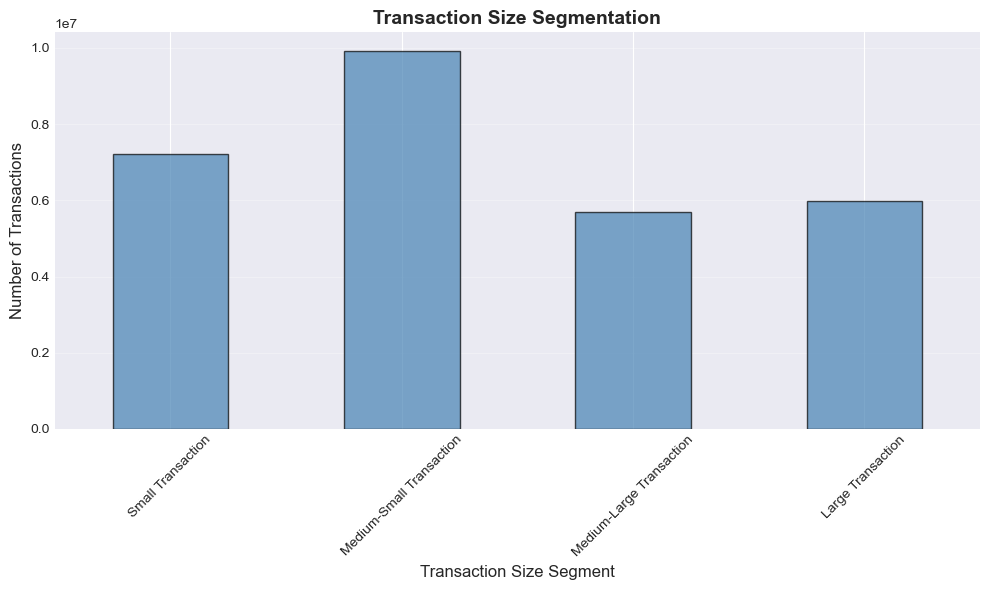


📊 TEMPORAL PATTERN SEGMENTATION
--------------------------------------------------------------------------------

Weekday vs Weekend Transactions:


,Count,Percentage
day_type,,
Weekday,20570069,71.390
Weekend,8243350,28.610


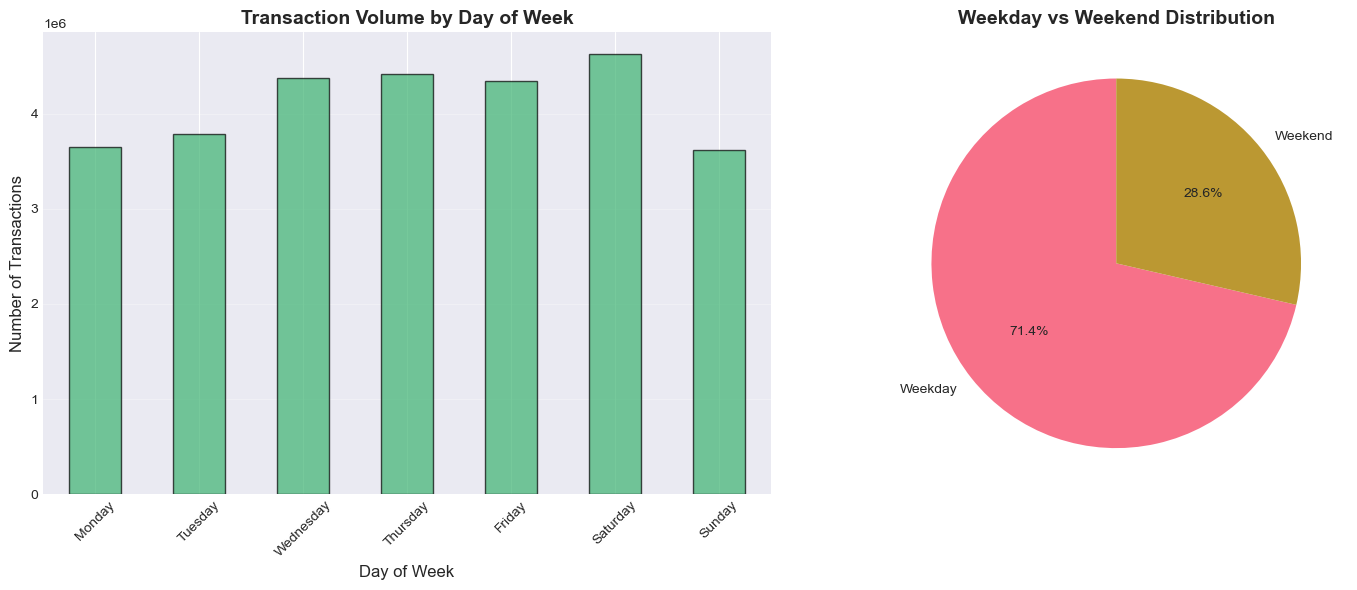


📊 SEASONAL PATTERN SEGMENTATION
--------------------------------------------------------------------------------

Seasonal Transaction Distribution:


,Count,Percentage
season,,
Summer,8497487,29.490
Spring,7269506,25.230
Fall,6937220,24.080
Winter,6109206,21.200


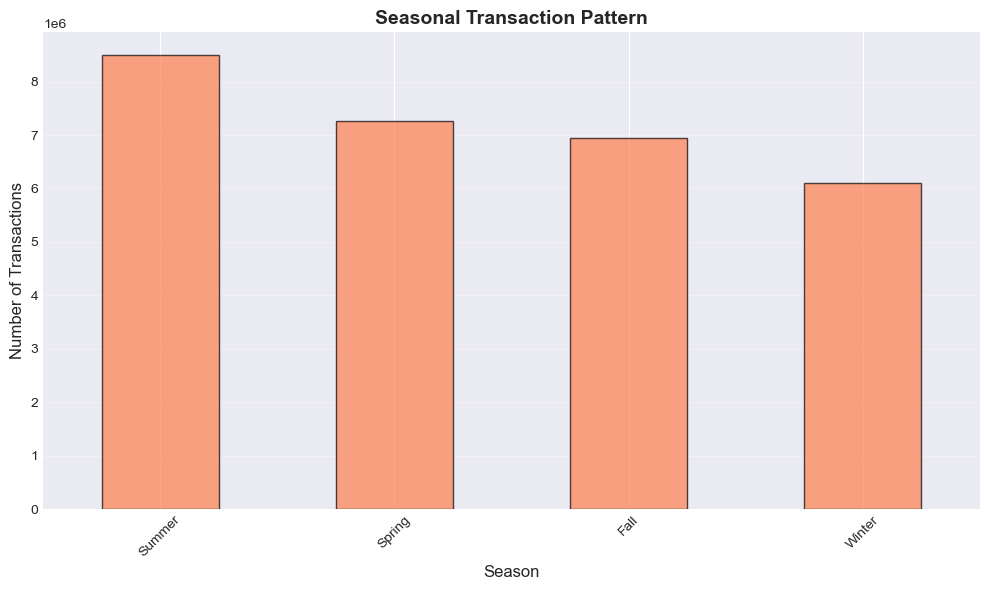


📊 SALES CHANNEL PATTERN SEGMENTATION
--------------------------------------------------------------------------------


,Count,Percentage
sales_channel_id,,
2,19686806,68.330
1,9126613,31.670


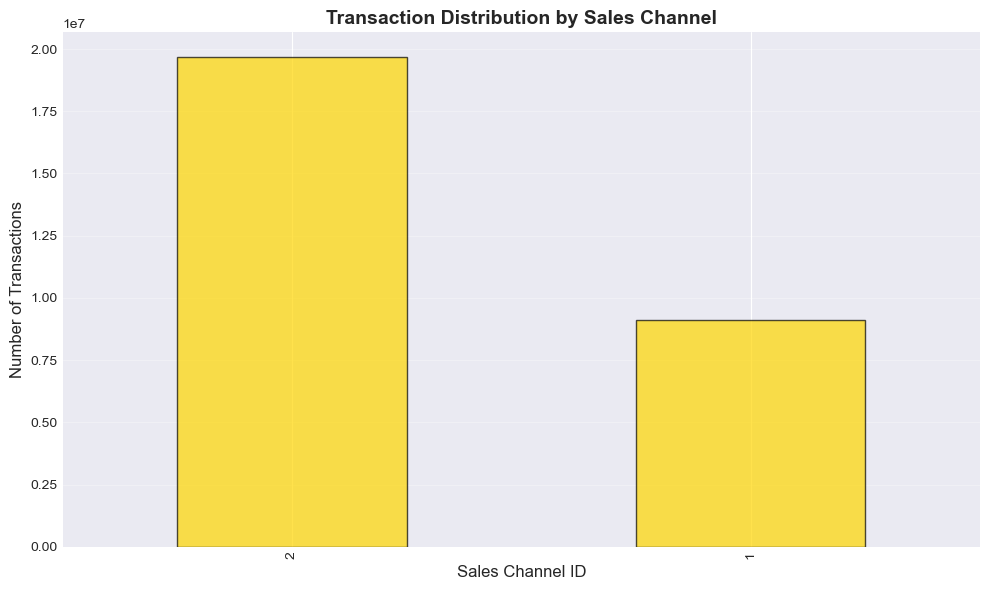


TRANSACTION PATTERN ANALYSIS COMPLETE


In [ ]:
# TRANSACTION PATTERNS AND SEGMENTATION
if transactions is not None:
    print("="*80)
    print("TRANSACTION PATTERNS AND SEGMENTATION")
    print("="*80)

    # Transaction pattern analysis
    print("\n📊 TRANSACTION PATTERN ANALYSIS")
    print("-" * 80)

    # Extract temporal features
    transactions['year'] = transactions['t_dat'].dt.year
    transactions['month'] = transactions['t_dat'].dt.month
    transactions['day_of_week'] = transactions['t_dat'].dt.day_name()
    transactions['day_of_month'] = transactions['t_dat'].dt.day
    transactions['hour'] = transactions['t_dat'].dt.hour if 'hour' in str(transactions['t_dat'].dtype) else None

    # Transaction size segmentation
    print("\n📊 TRANSACTION SIZE SEGMENTATION")
    print("-" * 80)

    if 'price' in transactions.columns:
        # Segment transactions by price
        price_quartiles = transactions['price'].quantile([0.25, 0.5, 0.75])
        transactions['transaction_size_segment'] = pd.cut(
            transactions['price'],
            bins=[0, price_quartiles[0.25], price_quartiles[0.5], price_quartiles[0.75], float('inf')],
            labels=['Small Transaction', 'Medium-Small Transaction', 'Medium-Large Transaction', 'Large Transaction']
        )

        size_seg_counts = transactions['transaction_size_segment'].value_counts().sort_index()
        size_seg_pct = transactions['transaction_size_segment'].value_counts(normalize=True).sort_index() * 100

        size_seg_df = pd.DataFrame({
            'Count': size_seg_counts,
            'Percentage': size_seg_pct.round(2)
        })
        display(size_seg_df)

        # Visualization
        plt.figure(figsize=(10, 6))
        size_seg_counts.plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.7)
        plt.title('Transaction Size Segmentation', fontsize=14, fontweight='bold')
        plt.xlabel('Transaction Size Segment', fontsize=12)
        plt.ylabel('Number of Transactions', fontsize=12)
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

    # Temporal pattern segmentation
    print("\n📊 TEMPORAL PATTERN SEGMENTATION")
    print("-" * 80)

    # Day of week pattern
    dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    dow_counts = transactions['day_of_week'].value_counts().reindex(dow_order)

    # Segment days into weekdays vs weekends
    transactions['day_type'] = transactions['day_of_week'].apply(
        lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday'
    )

    day_type_counts = transactions['day_type'].value_counts()
    day_type_pct = transactions['day_type'].value_counts(normalize=True) * 100

    day_type_df = pd.DataFrame({
        'Count': day_type_counts,
        'Percentage': day_type_pct.round(2)
    })
    print("\nWeekday vs Weekend Transactions:")
    display(day_type_df)

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    dow_counts.plot(kind='bar', ax=axes[0], color='mediumseagreen', edgecolor='black', alpha=0.7)
    axes[0].set_title('Transaction Volume by Day of Week', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Day of Week', fontsize=12)
    axes[0].set_ylabel('Number of Transactions', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, axis='y')

    day_type_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Weekday vs Weekend Distribution', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

    # Monthly pattern segmentation
    print("\n📊 SEASONAL PATTERN SEGMENTATION")
    print("-" * 80)

    # Create seasonal segments
    transactions['season'] = transactions['month'].apply(
        lambda x: 'Spring' if x in [3, 4, 5] else
                  'Summer' if x in [6, 7, 8] else
                  'Fall' if x in [9, 10, 11] else 'Winter'
    )

    season_counts = transactions['season'].value_counts()
    season_pct = transactions['season'].value_counts(normalize=True) * 100

    season_df = pd.DataFrame({
        'Count': season_counts,
        'Percentage': season_pct.round(2)
    })
    print("\nSeasonal Transaction Distribution:")
    display(season_df)

    # Visualization
    plt.figure(figsize=(10, 6))
    season_counts.plot(kind='bar', color='coral', edgecolor='black', alpha=0.7)
    plt.title('Seasonal Transaction Pattern', fontsize=14, fontweight='bold')
    plt.xlabel('Season', fontsize=12)
    plt.ylabel('Number of Transactions', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    # Sales channel pattern
    if 'sales_channel_id' in transactions.columns:
        print("\n📊 SALES CHANNEL PATTERN SEGMENTATION")
        print("-" * 80)

        channel_counts = transactions['sales_channel_id'].value_counts()
        channel_pct = transactions['sales_channel_id'].value_counts(normalize=True) * 100

        channel_df = pd.DataFrame({
            'Count': channel_counts,
            'Percentage': channel_pct.round(2)
        })
        display(channel_df)

        # Visualization
        plt.figure(figsize=(10, 6))
        channel_counts.plot(kind='bar', color='gold', edgecolor='black', alpha=0.7)
        plt.title('Transaction Distribution by Sales Channel', fontsize=14, fontweight='bold')
        plt.xlabel('Sales Channel ID', fontsize=12)
        plt.ylabel('Number of Transactions', fontsize=12)
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

    print("\n" + "="*80)
    print("TRANSACTION PATTERN ANALYSIS COMPLETE")
    print("="*80)
else:
    print("⚠ Transaction data not available")


## 4c. Engagement Segmentation

This section analyzes customer engagement levels and creates engagement-based segments.


ENGAGEMENT SEGMENTATION

📊 ENGAGEMENT METRICS CALCULATION
--------------------------------------------------------------------------------

Engagement Metrics Statistics:


,total_purchases,unique_purchase_days,total_spent,days_active
count,1362281.000,1362281.000,1362281.000,1362281.000
mean,21.151,6.665,0.586,273.391
std,34.590,9.707,1.048,269.962
min,1.000,1.000,0.001,0.000
25%,3.000,1.000,0.083,0.000
50%,9.000,3.000,0.226,206.000
75%,25.000,8.000,0.645,549.000
max,1641.000,427.000,49.361,733.000



📊 ENGAGEMENT SEGMENTATION
--------------------------------------------------------------------------------

Engagement Segmentation:


,Count,Percentage
engagement_segment,,
Low Engagement,1361774,99.960
Medium-Low Engagement,479,0.040
Medium-High Engagement,24,0.000
High Engagement,3,0.000


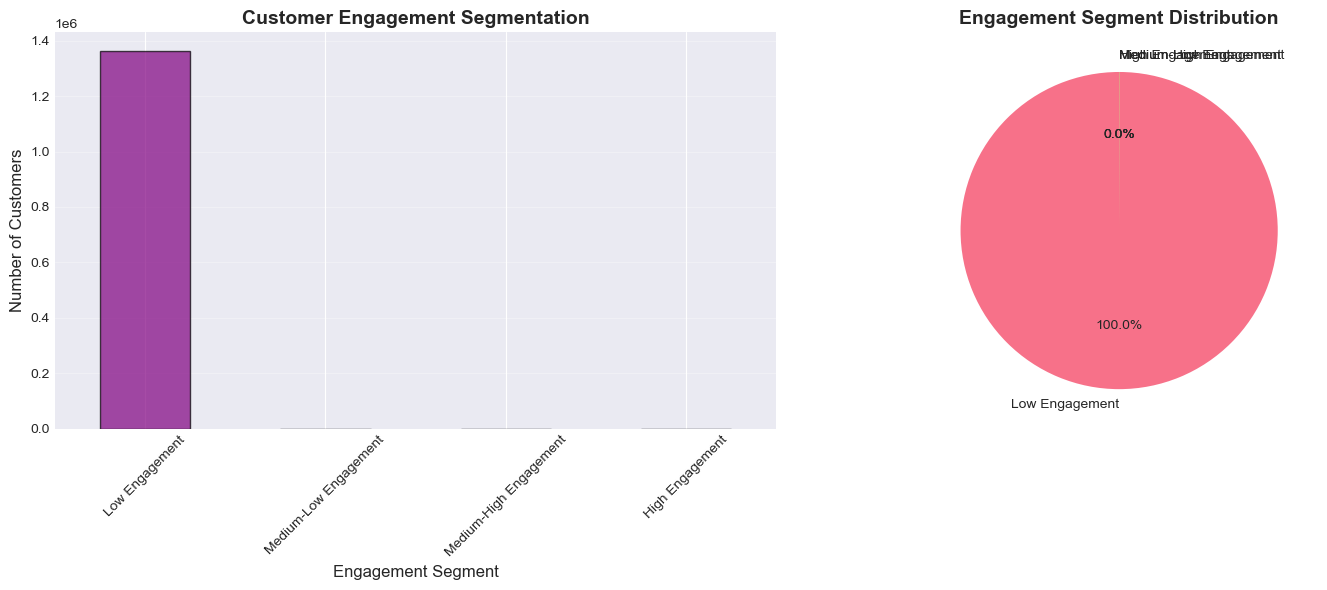


📊 ENGAGEMENT BY CUSTOMER ATTRIBUTES
--------------------------------------------------------------------------------

Engagement × Club Membership:


club_member_status,ACTIVE,LEFT CLUB,PRE-CREATE,UNKNOWN
engagement_segment,,,,
Low Engagement,1262679,466,92577,6052
Medium-Low Engagement,476,0,1,2
Medium-High Engagement,24,0,0,0
High Engagement,3,0,0,0


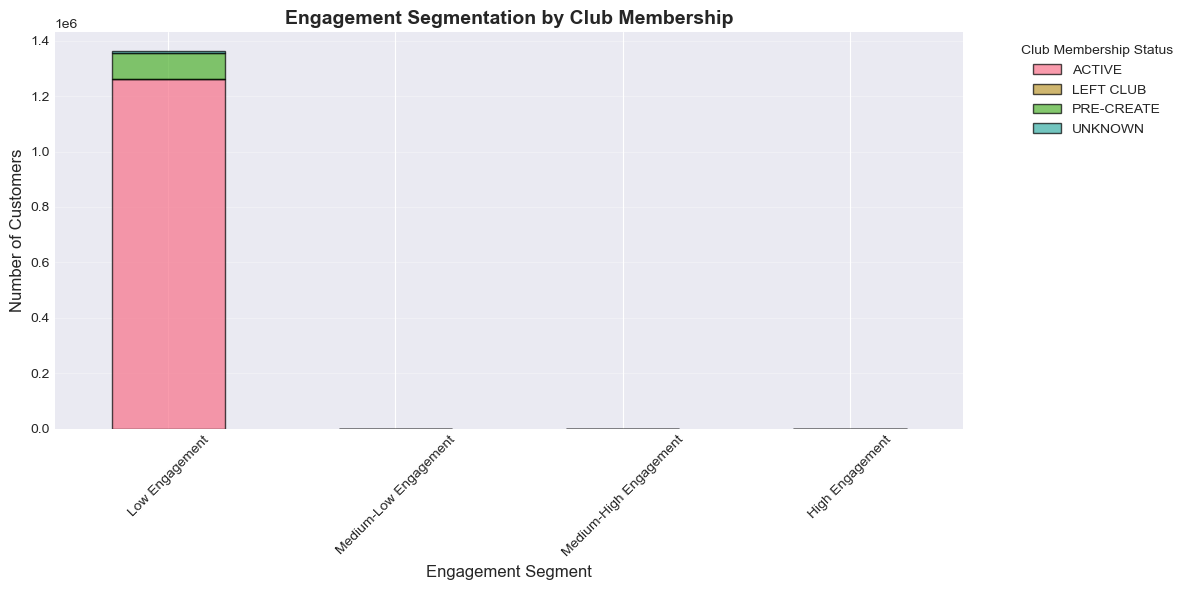


📊 ENGAGEMENT METRICS BY SEGMENT
--------------------------------------------------------------------------------

Average Engagement Metrics by Segment:


total_purchases          total_spent         \
                                  mean   median        mean median   
engagement_segment                                                   
Low Engagement                  20.968    9.000       0.580  0.226   
Medium-Low Engagement          489.299  475.000      16.451 15.873   
Medium-High Engagement         891.458  873.000      31.147 30.081   
High Engagement               1422.000 1321.000      47.590 49.205   

                       unique_purchase_days         days_active          
                                       mean  median        mean  median  
engagement_segment                                                       
Low Engagement                        6.622   3.000     273.228 205.000  
Medium-Low Engagement               118.163 110.000     709.944 721.000  
Medium-High Engagement              229.583 221.500     725.708 727.000  
High Engagement                     317.000 293.000     725.333 725.000


ENGAGEMENT SEGMENTATION COMPLETE


In [ ]:
# ENGAGEMENT SEGMENTATION
if transactions is not None and customers is not None:
    print("="*80)
    print("ENGAGEMENT SEGMENTATION")
    print("="*80)

    # Calculate engagement metrics
    print("\n📊 ENGAGEMENT METRICS CALCULATION")
    print("-" * 80)

    # Customer engagement metrics
    engagement_metrics = transactions.groupby('customer_id').agg({
        'article_id': 'count',  # Purchase frequency
        't_dat': ['min', 'max', 'nunique'],  # First purchase, last purchase, unique purchase days
        'price': 'sum'  # Total spending
    }).reset_index()

    engagement_metrics.columns = ['customer_id', 'total_purchases', 'first_purchase', 'last_purchase', 'unique_purchase_days', 'total_spent']

    # Calculate additional engagement metrics
    reference_date = transactions['t_dat'].max()
    engagement_metrics['days_active'] = (engagement_metrics['last_purchase'] - engagement_metrics['first_purchase']).dt.days
    engagement_metrics['days_since_last_purchase'] = (reference_date - engagement_metrics['last_purchase']).dt.days
    engagement_metrics['avg_days_between_purchases'] = engagement_metrics['days_active'] / (engagement_metrics['unique_purchase_days'] - 1)
    engagement_metrics['avg_transaction_value'] = engagement_metrics['total_spent'] / engagement_metrics['total_purchases']

    # Merge with customer data for additional engagement indicators
    engagement_metrics = engagement_metrics.merge(
        customers[['customer_id', 'club_member_status', 'fashion_news_frequency', 'active', 'fn']],
        on='customer_id',
        how='left'
    )

    print("\nEngagement Metrics Statistics:")
    display(engagement_metrics[['total_purchases', 'unique_purchase_days', 'total_spent', 'days_active']].describe())

    # Engagement segmentation
    print("\n📊 ENGAGEMENT SEGMENTATION")
    print("-" * 80)

    # Create engagement score (composite metric)
    # Normalize metrics to 0-1 scale
    from sklearn.preprocessing import MinMaxScaler

    scaler = MinMaxScaler()
    engagement_features = engagement_metrics[['total_purchases', 'unique_purchase_days', 'total_spent']].fillna(0)
    engagement_scaled = scaler.fit_transform(engagement_features)

    # Calculate composite engagement score
    engagement_metrics['engagement_score'] = (
        engagement_scaled[:, 0] * 0.4 +  # Purchase frequency weight
        engagement_scaled[:, 1] * 0.3 +  # Purchase diversity weight
        engagement_scaled[:, 2] * 0.3   # Spending weight
    )

    # Segment by engagement score
    engagement_metrics['engagement_segment'] = pd.cut(
        engagement_metrics['engagement_score'],
        bins=[0, 0.25, 0.5, 0.75, 1.0],
        labels=['Low Engagement', 'Medium-Low Engagement', 'Medium-High Engagement', 'High Engagement']
    )

    eng_seg_counts = engagement_metrics['engagement_segment'].value_counts().sort_index()
    eng_seg_pct = engagement_metrics['engagement_segment'].value_counts(normalize=True).sort_index() * 100

    eng_seg_df = pd.DataFrame({
        'Count': eng_seg_counts,
        'Percentage': eng_seg_pct.round(2)
    })
    print("\nEngagement Segmentation:")
    display(eng_seg_df)

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    eng_seg_counts.plot(kind='bar', ax=axes[0], color='purple', edgecolor='black', alpha=0.7)
    axes[0].set_title('Customer Engagement Segmentation', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Engagement Segment', fontsize=12)
    axes[0].set_ylabel('Number of Customers', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, axis='y')

    eng_seg_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Engagement Segment Distribution', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

    # Engagement by customer attributes
    print("\n📊 ENGAGEMENT BY CUSTOMER ATTRIBUTES")
    print("-" * 80)

    if 'club_member_status' in engagement_metrics.columns:
        eng_by_club = engagement_metrics.groupby(['engagement_segment', 'club_member_status']).size().unstack(fill_value=0)
        print("\nEngagement × Club Membership:")
        display(eng_by_club)

        # Visualization
        eng_by_club.plot(kind='bar', stacked=True, figsize=(12, 6), edgecolor='black', alpha=0.7)
        plt.title('Engagement Segmentation by Club Membership', fontsize=14, fontweight='bold')
        plt.xlabel('Engagement Segment', fontsize=12)
        plt.ylabel('Number of Customers', fontsize=12)
        plt.xticks(rotation=45)
        plt.legend(title='Club Membership Status', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

    # Engagement metrics by segment
    print("\n📊 ENGAGEMENT METRICS BY SEGMENT")
    print("-" * 80)

    eng_metrics_by_segment = engagement_metrics.groupby('engagement_segment').agg({
        'total_purchases': ['mean', 'median'],
        'total_spent': ['mean', 'median'],
        'unique_purchase_days': ['mean', 'median'],
        'days_active': ['mean', 'median']
    })

    print("\nAverage Engagement Metrics by Segment:")
    display(eng_metrics_by_segment)

    print("\n" + "="*80)
    print("ENGAGEMENT SEGMENTATION COMPLETE")
    print("="*80)
else:
    print("⚠ Cannot perform engagement segmentation - missing required datasets")


## 4d. Purchase Pattern Segmentation

This section analyzes customer purchase patterns and creates pattern-based segments.


PURCHASE PATTERN SEGMENTATION

📊 PURCHASE PATTERN ANALYSIS
--------------------------------------------------------------------------------

Purchase Pattern Statistics:


,total_purchases,unique_products,unique_purchase_days,avg_days_between_purchases
count,1362281.000,1362281.000,1362281.000,914308.000
mean,21.151,20.045,6.665,90.337
std,34.590,31.980,9.707,94.192
min,1.000,1.000,1.000,1.000
25%,3.000,3.000,1.000,34.125
50%,9.000,8.000,3.000,60.667
75%,25.000,24.000,8.000,109.833
max,1641.000,1346.000,427.000,731.000



📊 PURCHASE FREQUENCY PATTERN SEGMENTATION
--------------------------------------------------------------------------------

Purchase Frequency Pattern:


,Count
frequency_pattern,
Occasional Buyer,380275
Regular Buyer,335539
Frequent Buyer,316289
Very Frequent Buyer,330178



📊 PURCHASE CONSISTENCY PATTERN SEGMENTATION
--------------------------------------------------------------------------------

Purchase Consistency Pattern:


,Count
consistency_pattern,
Inconsistent,340571
Somewhat Consistent,340570
Consistent,340707
Very Consistent,340433



📊 PRODUCT DIVERSITY PATTERN SEGMENTATION
--------------------------------------------------------------------------------

Product Diversity Pattern:


,Count
diversity_pattern,
Low Diversity,342210
High Diversity,1020071



📊 COMBINED PURCHASE PATTERN SEGMENTATION
--------------------------------------------------------------------------------

Top 10 Purchase Pattern Combinations:


,Count
combined_pattern,
Occasional Buyer / Very Consistent / High Diversity,253775
Regular Buyer / Consistent / High Diversity,107534
Very Frequent Buyer / Inconsistent / Low Diversity,75169
Frequent Buyer / Consistent / High Diversity,73513
Very Frequent Buyer / Somewhat Consistent / Low Diversity,70615
Frequent Buyer / Somewhat Consistent / High Diversity,68483
Regular Buyer / Inconsistent / High Diversity,67213
Very Frequent Buyer / Somewhat Consistent / High Diversity,64033
Regular Buyer / Somewhat Consistent / High Diversity,63737


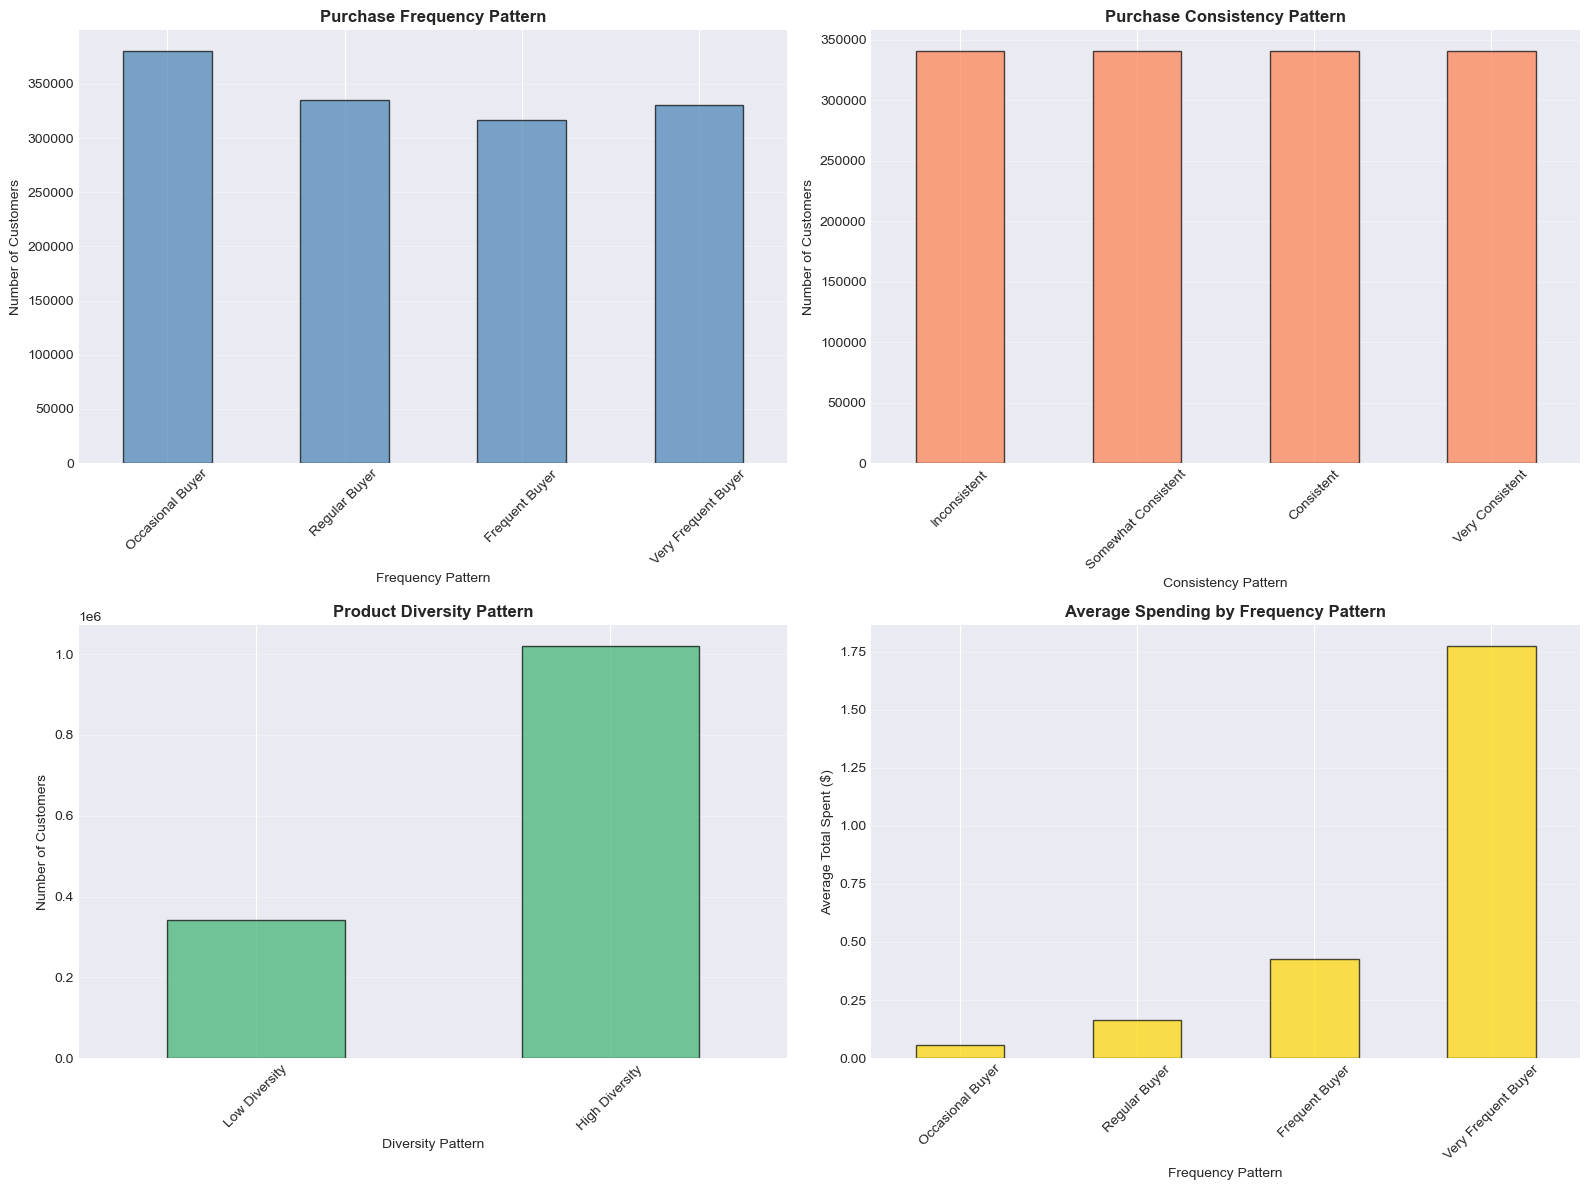


PURCHASE PATTERN SEGMENTATION COMPLETE


In [ ]:
# PURCHASE PATTERN SEGMENTATION
if transactions is not None and customers is not None:
    print("="*80)
    print("PURCHASE PATTERN SEGMENTATION")
    print("="*80)

    # Analyze purchase patterns
    print("\n📊 PURCHASE PATTERN ANALYSIS")
    print("-" * 80)

    # Customer purchase patterns
    purchase_patterns = transactions.groupby('customer_id').agg({
        'article_id': ['count', 'nunique'],  # Total purchases, unique products
        't_dat': ['min', 'max', 'nunique'],  # First, last, unique purchase dates
        'price': ['sum', 'mean', 'std'],  # Spending patterns
        'sales_channel_id': lambda x: x.mode()[0] if len(x.mode()) > 0 else None  # Preferred channel
    }).reset_index()

    purchase_patterns.columns = [
        'customer_id', 'total_purchases', 'unique_products',
        'first_purchase', 'last_purchase', 'unique_purchase_days',
        'total_spent', 'avg_spent', 'spending_std',
        'preferred_channel'
    ]

    # Calculate pattern metrics
    reference_date = transactions['t_dat'].max()
    purchase_patterns['purchase_span_days'] = (purchase_patterns['last_purchase'] - purchase_patterns['first_purchase']).dt.days
    purchase_patterns['avg_days_between_purchases'] = purchase_patterns['purchase_span_days'] / (purchase_patterns['unique_purchase_days'] - 1)
    purchase_patterns['products_per_purchase'] = purchase_patterns['total_purchases'] / purchase_patterns['unique_purchase_days']
    purchase_patterns['product_diversity'] = purchase_patterns['unique_products'] / purchase_patterns['total_purchases']

    print("\nPurchase Pattern Statistics:")
    display(purchase_patterns[['total_purchases', 'unique_products', 'unique_purchase_days', 'avg_days_between_purchases']].describe())

    # Purchase frequency pattern segmentation
    print("\n📊 PURCHASE FREQUENCY PATTERN SEGMENTATION")
    print("-" * 80)

    # Segment by purchase frequency
    freq_quartiles = purchase_patterns['total_purchases'].quantile([0.25, 0.5, 0.75])
    purchase_patterns['frequency_pattern'] = pd.cut(
        purchase_patterns['total_purchases'],
        bins=[0, freq_quartiles[0.25], freq_quartiles[0.5], freq_quartiles[0.75], float('inf')],
        labels=['Occasional Buyer', 'Regular Buyer', 'Frequent Buyer', 'Very Frequent Buyer']
    )

    freq_pattern_counts = purchase_patterns['frequency_pattern'].value_counts().sort_index()
    print("\nPurchase Frequency Pattern:")
    display(freq_pattern_counts.to_frame('Count'))

    # Purchase consistency pattern
    print("\n📊 PURCHASE CONSISTENCY PATTERN SEGMENTATION")
    print("-" * 80)

    # Segment by purchase consistency (lower std = more consistent)
    purchase_patterns['consistency_score'] = 1 / (1 + purchase_patterns['spending_std'].fillna(0))
    consistency_quartiles = purchase_patterns['consistency_score'].quantile([0.25, 0.5, 0.75])
    purchase_patterns['consistency_pattern'] = pd.cut(
        purchase_patterns['consistency_score'],
        bins=[0, consistency_quartiles[0.25], consistency_quartiles[0.5], consistency_quartiles[0.75], 1.0],
        labels=['Inconsistent', 'Somewhat Consistent', 'Consistent', 'Very Consistent']
    )

    consistency_pattern_counts = purchase_patterns['consistency_pattern'].value_counts().sort_index()
    print("\nPurchase Consistency Pattern:")
    display(consistency_pattern_counts.to_frame('Count'))

    # Product diversity pattern
    print("\n📊 PRODUCT DIVERSITY PATTERN SEGMENTATION")
    print("-" * 80)

    # Segment by product diversity
    # Handle potential duplicate bin edges by using qcut or creating unique bins
    try:
        # Try using qcut first (handles duplicates better)
        purchase_patterns['diversity_pattern'] = pd.qcut(
            purchase_patterns['product_diversity'],
            q=4,
            labels=['Low Diversity', 'Medium-Low Diversity', 'Medium-High Diversity', 'High Diversity'],
            duplicates='drop'
        )
    except (ValueError, TypeError):
        # If qcut fails, use cut with unique bins
        diversity_quartiles = purchase_patterns['product_diversity'].quantile([0.25, 0.5, 0.75])
        max_diversity = purchase_patterns['product_diversity'].max()

        # Create bins and ensure uniqueness
        bins = [0, diversity_quartiles[0.25], diversity_quartiles[0.5], diversity_quartiles[0.75], max_diversity]
        # Remove duplicates while preserving order
        unique_bins = []
        seen = set()
        for b in bins:
            if b not in seen:
                unique_bins.append(b)
                seen.add(b)

        # Adjust labels based on number of unique bins
        if len(unique_bins) == 5:
            labels = ['Low Diversity', 'Medium-Low Diversity', 'Medium-High Diversity', 'High Diversity']
        elif len(unique_bins) == 4:
            labels = ['Low Diversity', 'Medium Diversity', 'High Diversity']
        elif len(unique_bins) == 3:
            labels = ['Low Diversity', 'High Diversity']
        else:
            # If we can't create meaningful bins, assign all to one category
            purchase_patterns['diversity_pattern'] = 'Medium Diversity'
            unique_bins = None

        if unique_bins is not None:
            purchase_patterns['diversity_pattern'] = pd.cut(
                purchase_patterns['product_diversity'],
                bins=unique_bins,
                labels=labels[:len(unique_bins)-1] if len(unique_bins) > 2 else labels,
                duplicates='drop',
                include_lowest=True
            )

    diversity_pattern_counts = purchase_patterns['diversity_pattern'].value_counts().sort_index()
    print("\nProduct Diversity Pattern:")
    display(diversity_pattern_counts.to_frame('Count'))

    # Combined purchase pattern segmentation
    print("\n📊 COMBINED PURCHASE PATTERN SEGMENTATION")
    print("-" * 80)

    # Create combined pattern
    purchase_patterns['combined_pattern'] = (
        purchase_patterns['frequency_pattern'].astype(str) + " / " +
        purchase_patterns['consistency_pattern'].astype(str) + " / " +
        purchase_patterns['diversity_pattern'].astype(str)
    )

    # Top pattern combinations
    top_patterns = purchase_patterns['combined_pattern'].value_counts().head(10)
    print("\nTop 10 Purchase Pattern Combinations:")
    display(top_patterns.to_frame('Count'))

    # Visualization of key patterns
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    freq_pattern_counts.plot(kind='bar', ax=axes[0, 0], color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Purchase Frequency Pattern', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Frequency Pattern', fontsize=10)
    axes[0, 0].set_ylabel('Number of Customers', fontsize=10)
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].grid(True, alpha=0.3, axis='y')

    consistency_pattern_counts.plot(kind='bar', ax=axes[0, 1], color='coral', edgecolor='black', alpha=0.7)
    axes[0, 1].set_title('Purchase Consistency Pattern', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Consistency Pattern', fontsize=10)
    axes[0, 1].set_ylabel('Number of Customers', fontsize=10)
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(True, alpha=0.3, axis='y')

    diversity_pattern_counts.plot(kind='bar', ax=axes[1, 0], color='mediumseagreen', edgecolor='black', alpha=0.7)
    axes[1, 0].set_title('Product Diversity Pattern', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Diversity Pattern', fontsize=10)
    axes[1, 0].set_ylabel('Number of Customers', fontsize=10)
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    # Average spending by pattern
    pattern_spending = purchase_patterns.groupby('frequency_pattern')['total_spent'].mean().sort_index()
    pattern_spending.plot(kind='bar', ax=axes[1, 1], color='gold', edgecolor='black', alpha=0.7)
    axes[1, 1].set_title('Average Spending by Frequency Pattern', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Frequency Pattern', fontsize=10)
    axes[1, 1].set_ylabel('Average Total Spent ($)', fontsize=10)
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print("\n" + "="*80)
    print("PURCHASE PATTERN SEGMENTATION COMPLETE")
    print("="*80)
else:
    print("⚠ Cannot perform purchase pattern segmentation - missing required datasets")


ARTICLES/PRODUCT DATA EXPLORATION

📦 PRODUCT CATEGORY ANALYSIS
--------------------------------------------------------------------------------

Top 15 Departments by Product Count:


,Product Count
department_name,
Jersey,4604
Knitwear,3496
Trouser,2652
Blouse,2361
Dress,2087
Swimwear,2075
Kids Girl Jersey Fancy,2032
Expressive Lingerie,1910
Young Girl Jersey Fancy,1874


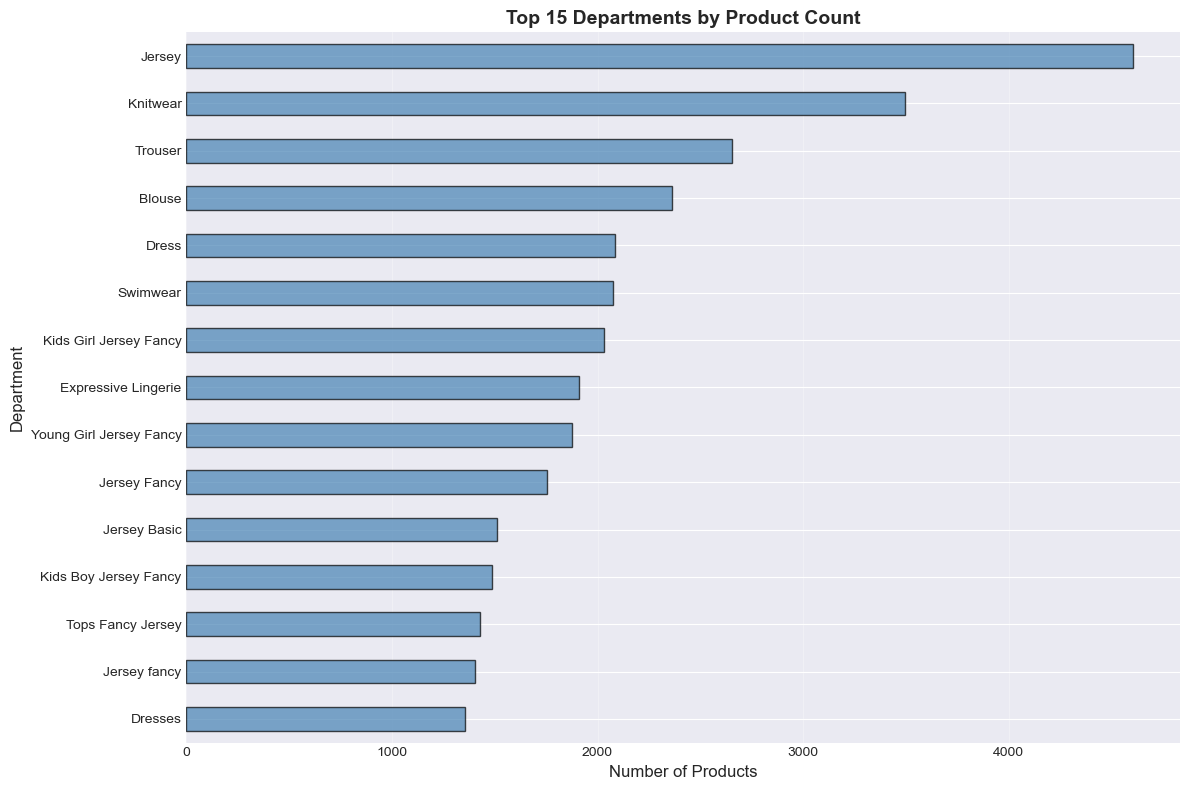


Top 15 Product Groups by Product Count:


,Product Count
product_group_name,
Garment Upper body,42741
Garment Lower body,19812
Garment Full body,13292
Accessories,11158
Underwear,5490
Shoes,5283
Swimwear,3127
Socks & Tights,2442
Nightwear,1899


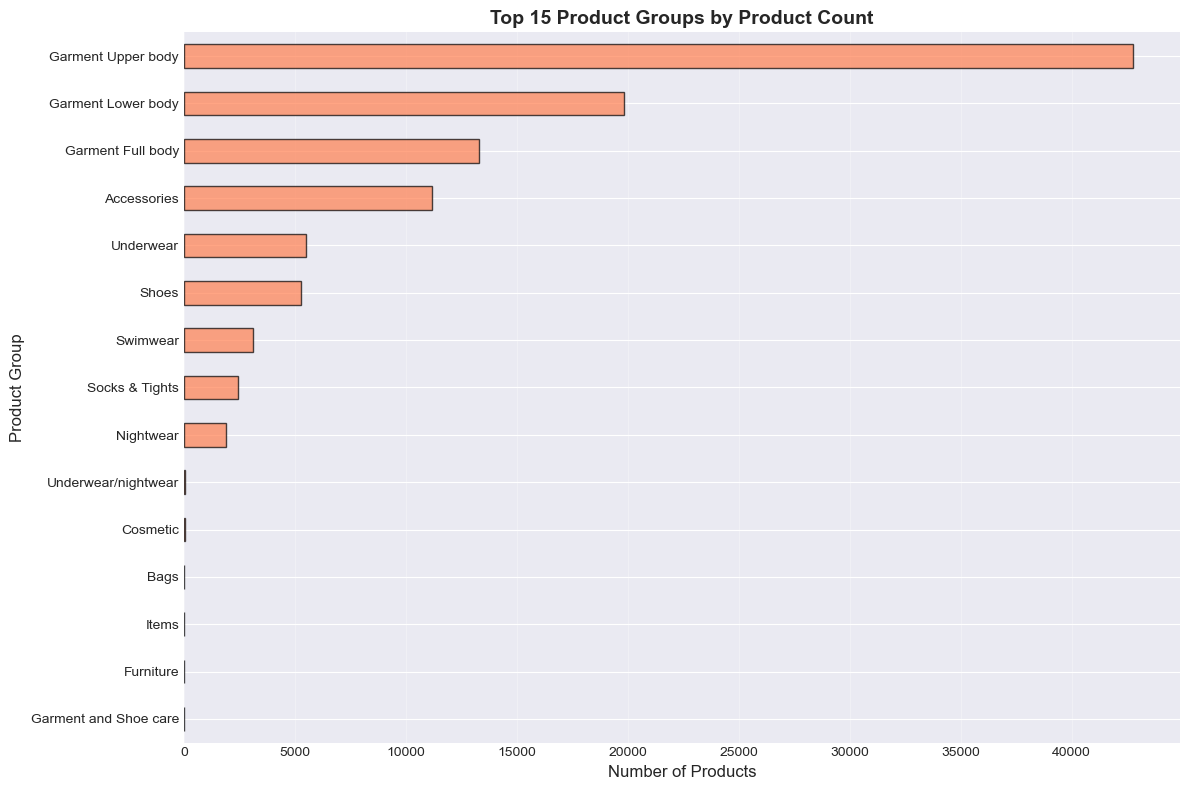


Top 20 Product Types by Product Count:


,Product Count
product_type_name,
Trousers,11169
Dress,10362
Sweater,9302
T-shirt,7904
Top,4155
Blouse,3979
Jacket,3940
Shorts,3939
Shirt,3405



Product Distribution by Index/Collection:


,Product Count
index_name,
Ladieswear,25992
Divided,15132
Menswear,12525
Children Sizes 92-140,12004
Children Sizes 134-170,9212
Baby Sizes 50-98,8872
Ladies Accessories,6956
Lingeries/Tights,6733
"Children Accessories, Swimwear",4614


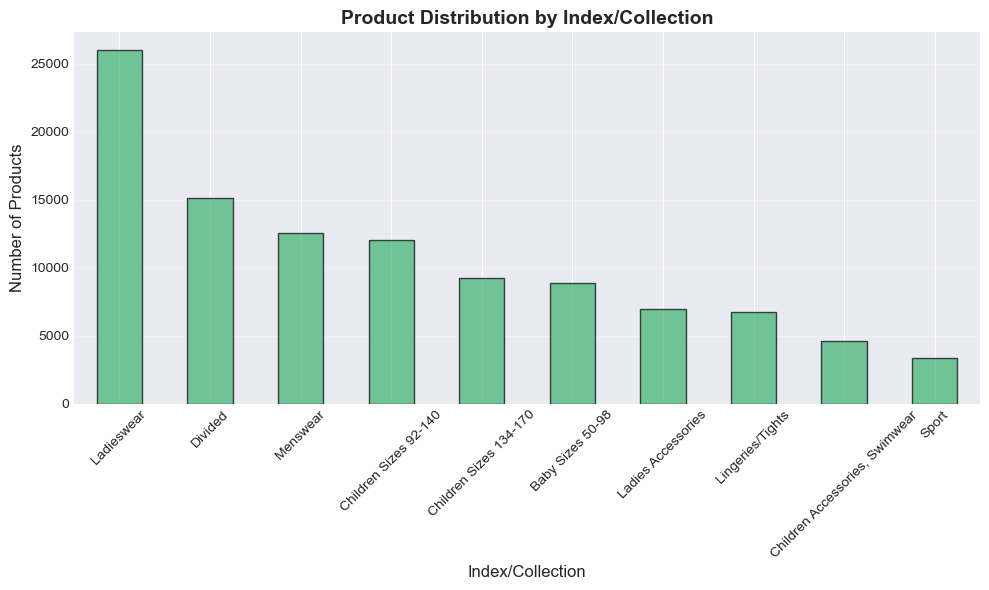


Top 15 Colors by Product Count:


,Product Count
colour_group_name,
Black,22627
Dark Blue,12162
White,9527
Light Pink,5808
Grey,4482
Light Beige,3351
Blue,3300
Red,3055
Light Blue,3010


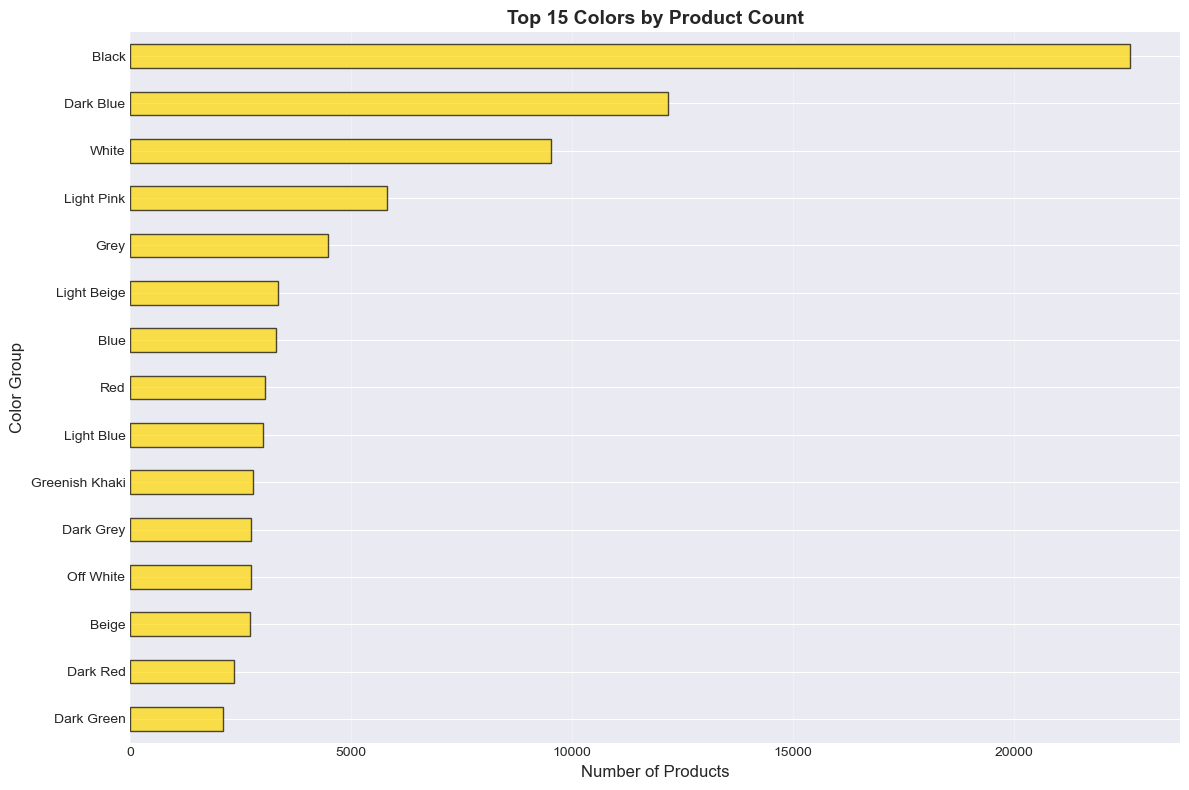


Product Distribution by Graphical Appearance:


,Product Count
graphical_appearance_name,
Solid,49664
All over pattern,17158
Melange,5930
Stripe,4990
Denim,4822
Front print,3215
Placement print,3097
Check,2178
Colour blocking,1830


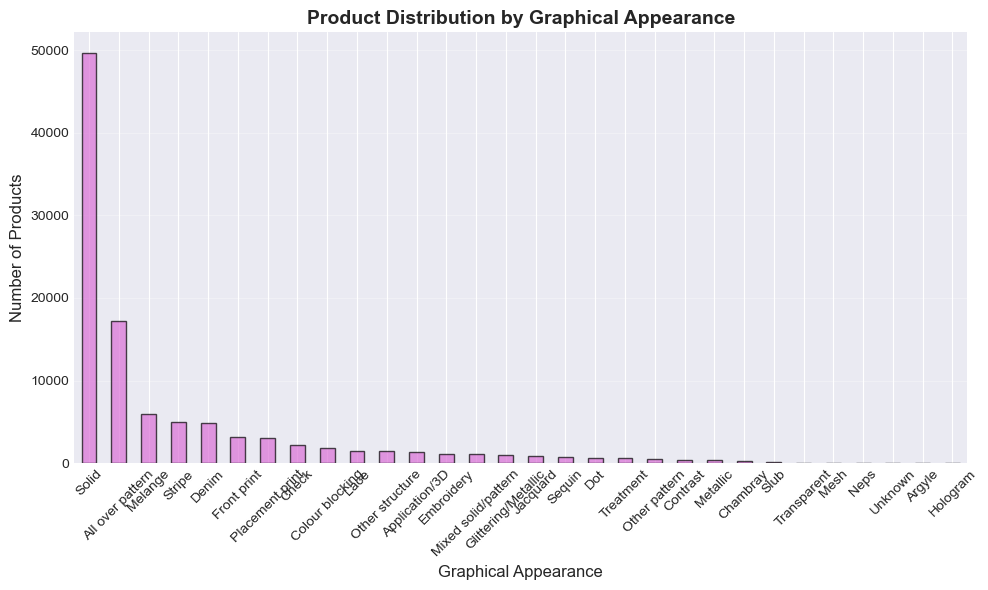


Top 15 Sections by Product Count:


,Product Count
section_name,
Womens Everyday Collection,7294
Divided Collection,7119
Baby Essentials & Complements,4932
Kids Girl,4466
Young Girl,3899
Womens Lingerie,3559
Girls Underwear & Basics,3489
Womens Tailoring,3374
Kids Boy,3328



📊 PRODUCT DATA SUMMARY STATISTICS
--------------------------------------------------------------------------------

Number of unique values in categorical columns:
   prod_name: 45,240 unique values
   product_type_name: 130 unique values
   product_group_name: 18 unique values
   graphical_appearance_name: 30 unique values
   colour_group_name: 50 unique values
   perceived_colour_value_name: 8 unique values
   perceived_colour_master_name: 20 unique values
   department_name: 250 unique values
   index_code: 10 unique values
   index_name: 10 unique values


In [ ]:
# ARTICLES/PRODUCT DATA EXPLORATION
if articles is not None:
    print("="*80)
    print("ARTICLES/PRODUCT DATA EXPLORATION")
    print("="*80)

    # Product Categories Analysis
    print("\n📦 PRODUCT CATEGORY ANALYSIS")
    print("-" * 80)

    # Department analysis
    if 'department_name' in articles.columns:
        dept_counts = articles['department_name'].value_counts().head(15)
        print("\nTop 15 Departments by Product Count:")
        display(dept_counts.to_frame('Product Count'))

        # Visualization
        plt.figure(figsize=(12, 8))
        dept_counts.plot(kind='barh', color='steelblue', edgecolor='black', alpha=0.7)
        plt.title('Top 15 Departments by Product Count', fontsize=14, fontweight='bold')
        plt.xlabel('Number of Products', fontsize=12)
        plt.ylabel('Department', fontsize=12)
        plt.gca().invert_yaxis()
        plt.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()

    # Product group analysis
    if 'product_group_name' in articles.columns:
        pg_counts = articles['product_group_name'].value_counts().head(15)
        print("\nTop 15 Product Groups by Product Count:")
        display(pg_counts.to_frame('Product Count'))

        # Visualization
        plt.figure(figsize=(12, 8))
        pg_counts.plot(kind='barh', color='coral', edgecolor='black', alpha=0.7)
        plt.title('Top 15 Product Groups by Product Count', fontsize=14, fontweight='bold')
        plt.xlabel('Number of Products', fontsize=12)
        plt.ylabel('Product Group', fontsize=12)
        plt.gca().invert_yaxis()
        plt.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()

    # Product type analysis
    if 'product_type_name' in articles.columns:
        pt_counts = articles['product_type_name'].value_counts().head(20)
        print("\nTop 20 Product Types by Product Count:")
        display(pt_counts.to_frame('Product Count'))

    # Index/Collection analysis
    if 'index_name' in articles.columns:
        index_counts = articles['index_name'].value_counts()
        print("\nProduct Distribution by Index/Collection:")
        display(index_counts.to_frame('Product Count'))

        # Visualization
        plt.figure(figsize=(10, 6))
        index_counts.plot(kind='bar', color='mediumseagreen', edgecolor='black', alpha=0.7)
        plt.title('Product Distribution by Index/Collection', fontsize=14, fontweight='bold')
        plt.xlabel('Index/Collection', fontsize=12)
        plt.ylabel('Number of Products', fontsize=12)
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

    # Color analysis
    if 'colour_group_name' in articles.columns:
        color_counts = articles['colour_group_name'].value_counts().head(15)
        print("\nTop 15 Colors by Product Count:")
        display(color_counts.to_frame('Product Count'))

        # Visualization
        plt.figure(figsize=(12, 8))
        color_counts.plot(kind='barh', color='gold', edgecolor='black', alpha=0.7)
        plt.title('Top 15 Colors by Product Count', fontsize=14, fontweight='bold')
        plt.xlabel('Number of Products', fontsize=12)
        plt.ylabel('Color Group', fontsize=12)
        plt.gca().invert_yaxis()
        plt.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()

    # Graphical appearance analysis
    if 'graphical_appearance_name' in articles.columns:
        graph_counts = articles['graphical_appearance_name'].value_counts()
        print("\nProduct Distribution by Graphical Appearance:")
        display(graph_counts.to_frame('Product Count'))

        # Visualization
        plt.figure(figsize=(10, 6))
        graph_counts.plot(kind='bar', color='orchid', edgecolor='black', alpha=0.7)
        plt.title('Product Distribution by Graphical Appearance', fontsize=14, fontweight='bold')
        plt.xlabel('Graphical Appearance', fontsize=12)
        plt.ylabel('Number of Products', fontsize=12)
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

    # Section analysis
    if 'section_name' in articles.columns:
        section_counts = articles['section_name'].value_counts().head(15)
        print("\nTop 15 Sections by Product Count:")
        display(section_counts.to_frame('Product Count'))

    # Summary statistics
    print("\n📊 PRODUCT DATA SUMMARY STATISTICS")
    print("-" * 80)

    categorical_cols = articles.select_dtypes(include=['object']).columns
    print(f"\nNumber of unique values in categorical columns:")
    for col in categorical_cols[:10]:  # Show first 10
        unique_count = articles[col].nunique()
        print(f"   {col}: {unique_count:,} unique values")
else:
    print("⚠ Articles data not available")


## 4. Transaction Data Exploration

This section analyzes transaction patterns, sales trends, pricing, and temporal patterns.


TRANSACTION DATA EXPLORATION

💰 TRANSACTION SUMMARY STATISTICS
--------------------------------------------------------------------------------

Price Statistics:


,count,mean,std,min,25%,50%,75%,max
price,28813419.000,0.028,0.019,0.000,0.016,0.025,0.034,0.592


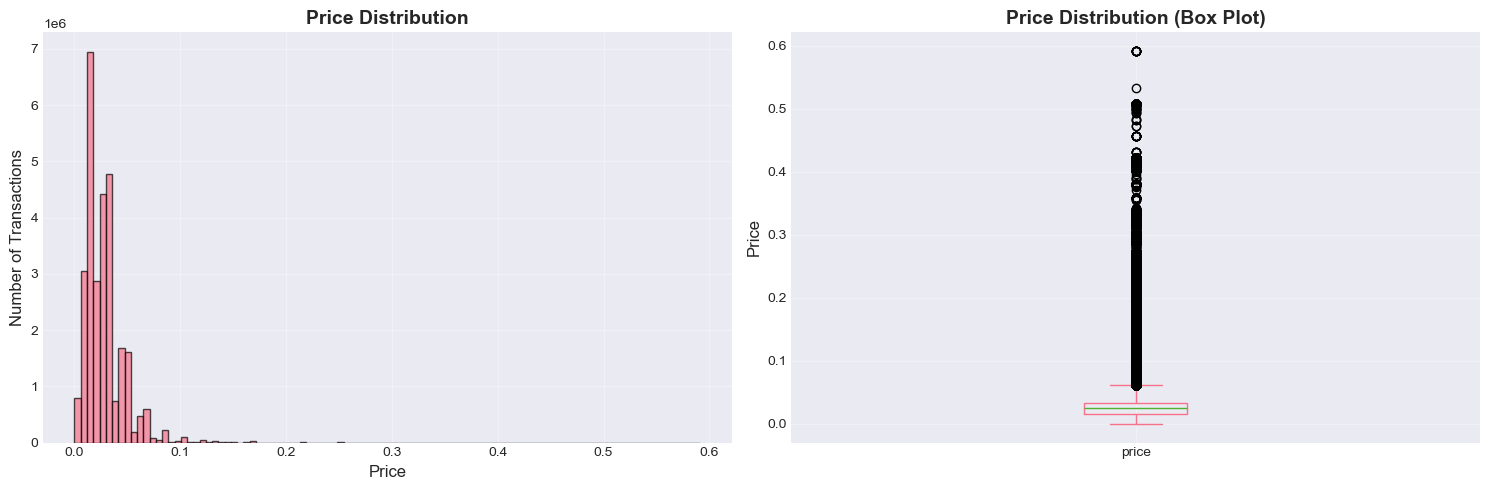


Price Statistics by Sales Channel:


,count,mean,std,min,25%,50%,75%,max
sales_channel_id,,,,,,,,
1,9126613.000,0.023,0.015,0.000,0.014,0.019,0.030,0.532
2,19686806.000,0.030,0.020,0.000,0.017,0.025,0.034,0.592


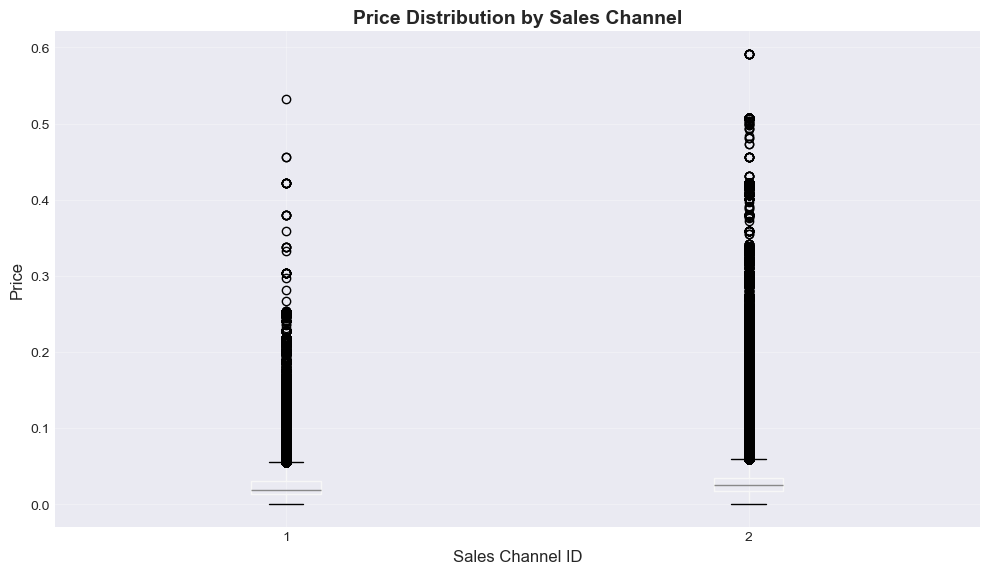


📅 TEMPORAL ANALYSIS
--------------------------------------------------------------------------------

Date Range: 2018-09-20 to 2020-09-22
Total Days: 734 days
Average Transactions per Day: 39,255
Median Transactions per Day: 35,754


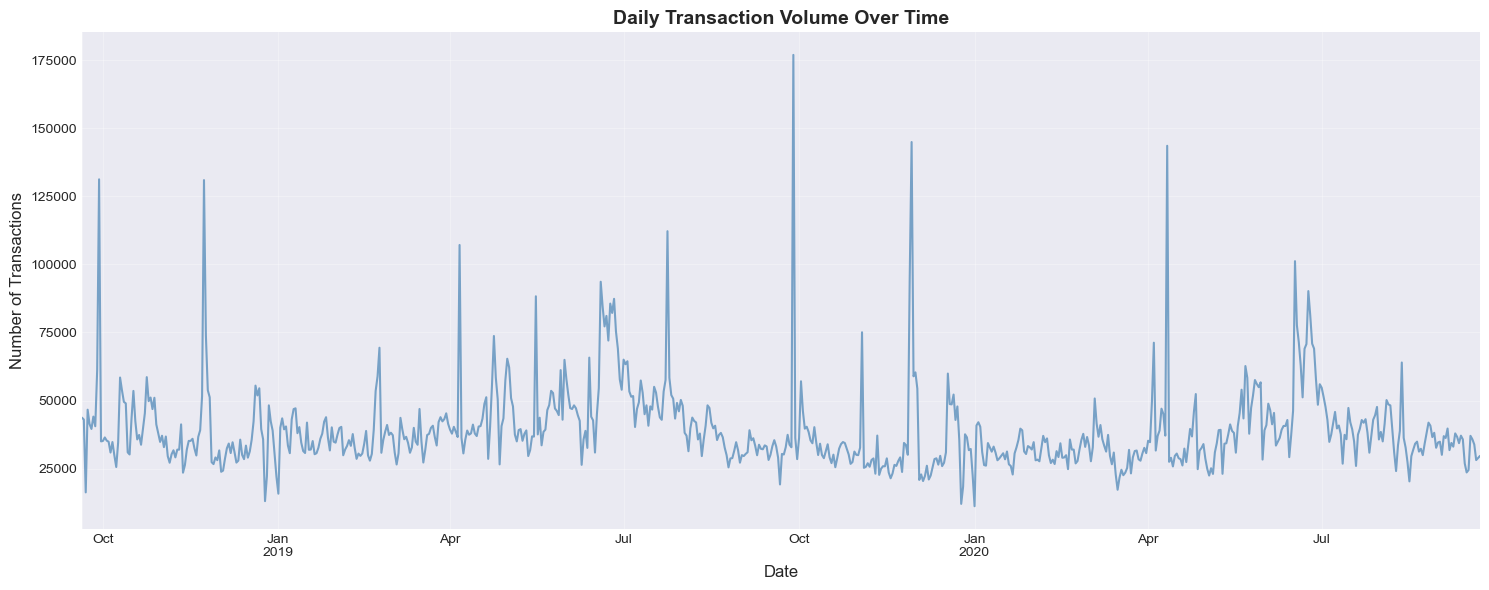

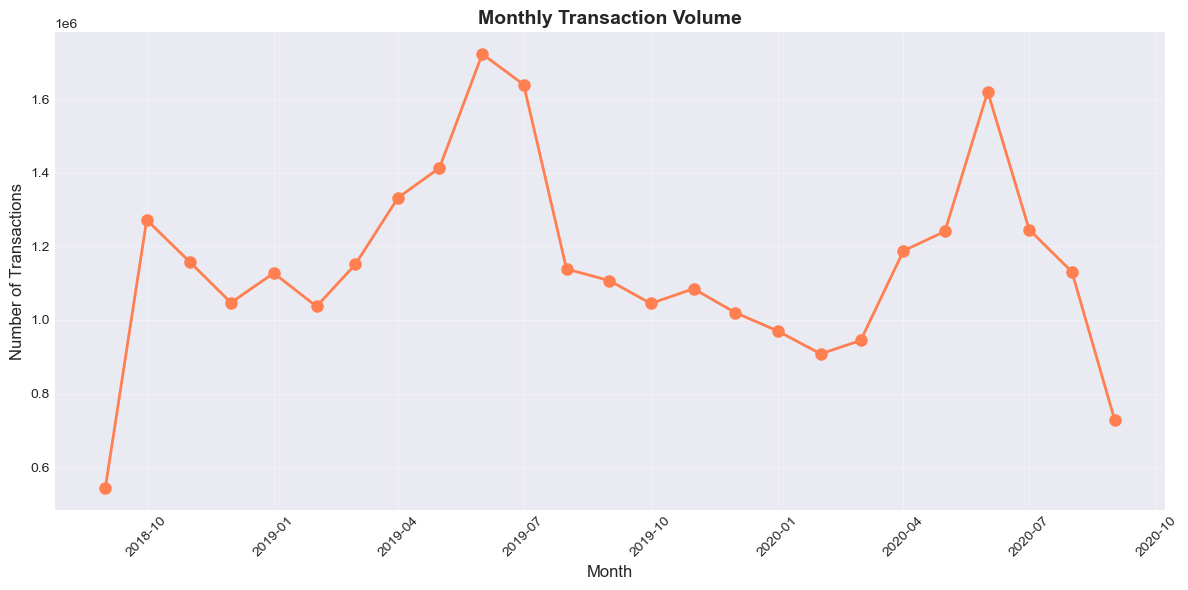


Transactions by Day of Week:


,Transaction Count
day_of_week,
Monday,3647226
Tuesday,3790428
Wednesday,4379833
Thursday,4411619
Friday,4340963
Saturday,4623424
Sunday,3619926


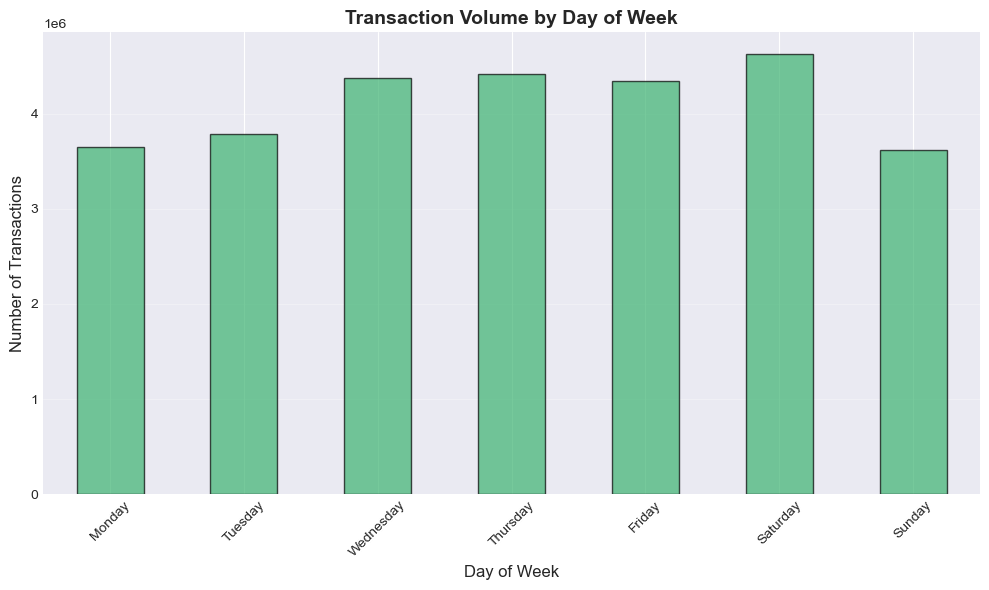


📊 SALES CHANNEL ANALYSIS
--------------------------------------------------------------------------------


,Count,Percentage
sales_channel_id,,
2,19686806,68.330
1,9126613,31.670


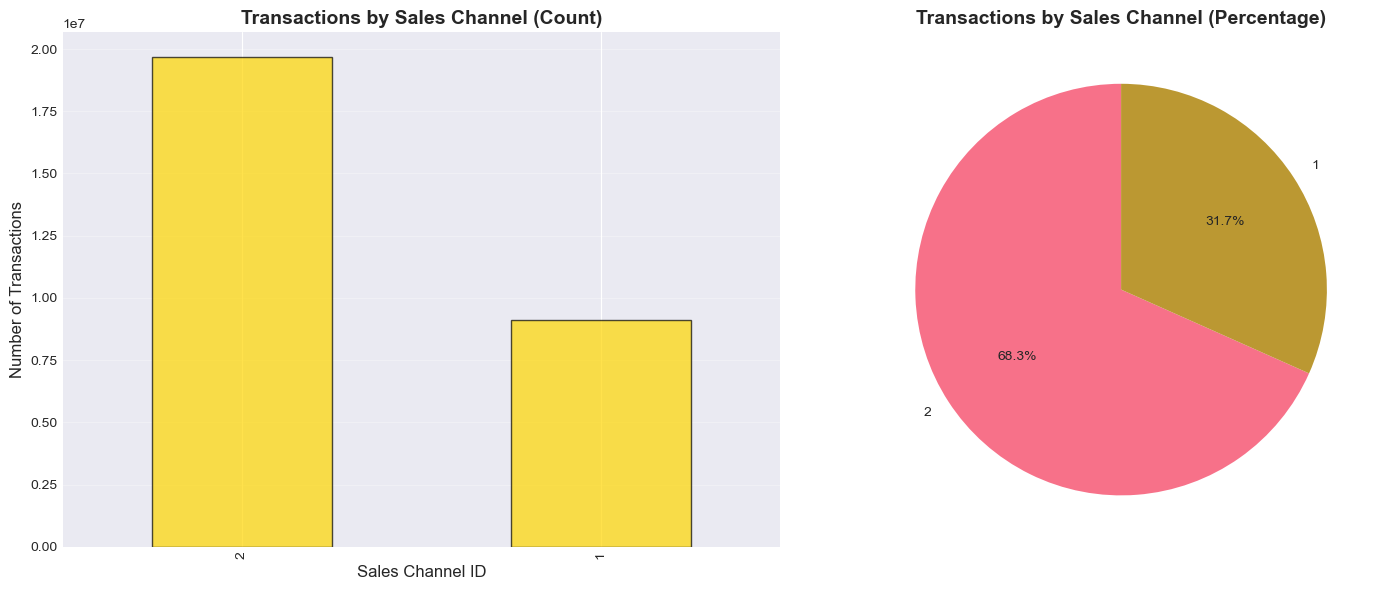


💰 REVENUE ANALYSIS
--------------------------------------------------------------------------------

Total Revenue: $798,958.07
Average Daily Revenue: $1,088.50
Median Daily Revenue: $1,023.24


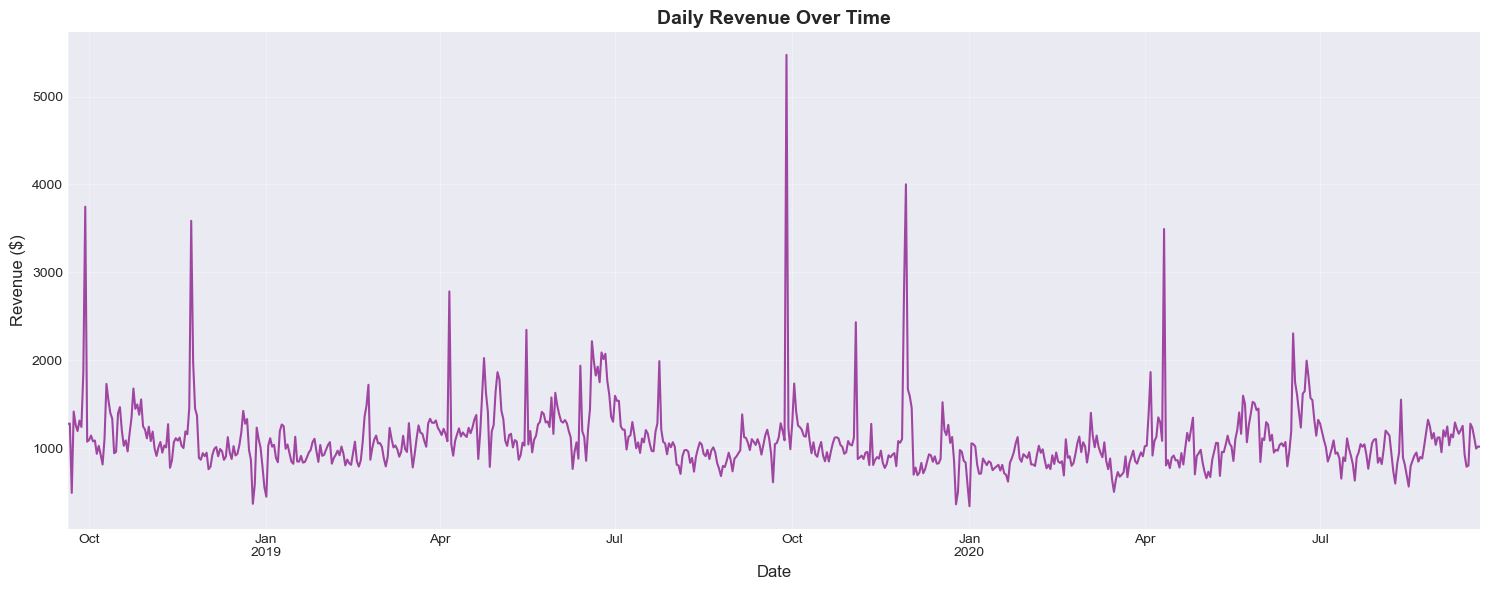

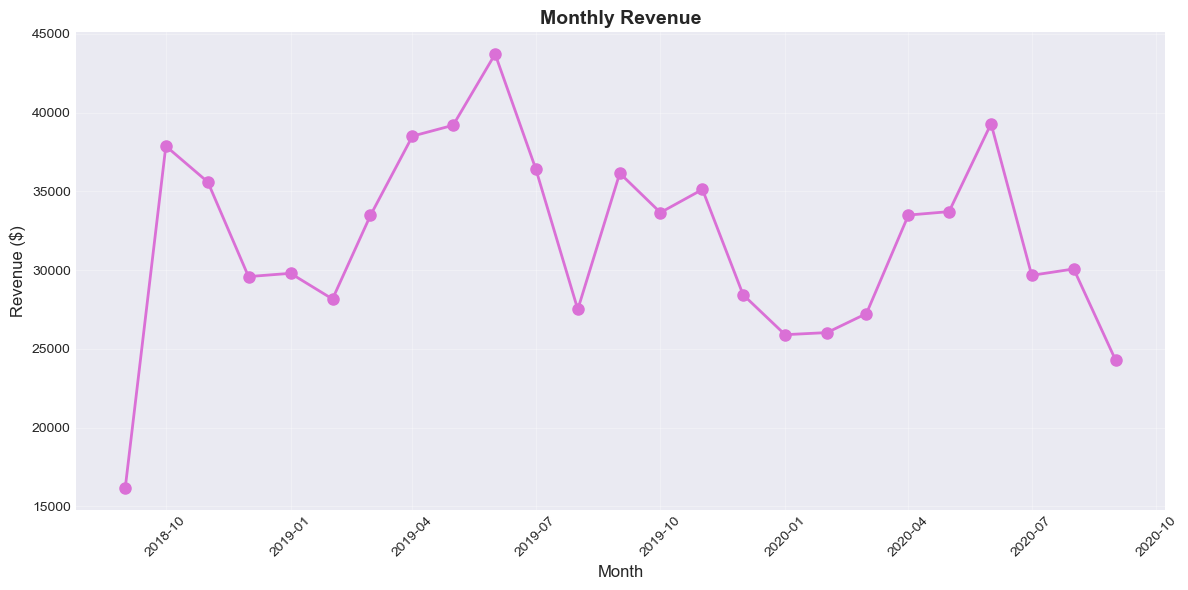

In [ ]:
# TRANSACTION DATA EXPLORATION
if transactions is not None:
    print("="*80)
    print("TRANSACTION DATA EXPLORATION")
    print("="*80)

    # Basic transaction statistics
    print("\n💰 TRANSACTION SUMMARY STATISTICS")
    print("-" * 80)

    if 'price' in transactions.columns:
        price_stats = transactions['price'].describe()
        print("\nPrice Statistics:")
        display(pd.DataFrame(price_stats).T)

        # Price distribution visualization
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # Histogram
        transactions['price'].hist(bins=100, ax=axes[0], edgecolor='black', alpha=0.7)
        axes[0].set_title('Price Distribution', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Price', fontsize=12)
        axes[0].set_ylabel('Number of Transactions', fontsize=12)
        axes[0].grid(True, alpha=0.3)

        # Box plot
        transactions['price'].plot(kind='box', ax=axes[1], vert=True)
        axes[1].set_title('Price Distribution (Box Plot)', fontsize=14, fontweight='bold')
        axes[1].set_ylabel('Price', fontsize=12)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Price statistics by sales channel
        if 'sales_channel_id' in transactions.columns:
            print("\nPrice Statistics by Sales Channel:")
            channel_price_stats = transactions.groupby('sales_channel_id')['price'].describe()
            display(channel_price_stats)

            # Visualization
            plt.figure(figsize=(10, 6))
            transactions.boxplot(column='price', by='sales_channel_id', ax=plt.gca())
            plt.title('Price Distribution by Sales Channel', fontsize=14, fontweight='bold')
            plt.suptitle('')  # Remove default title
            plt.xlabel('Sales Channel ID', fontsize=12)
            plt.ylabel('Price', fontsize=12)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

    # Temporal analysis
    print("\n📅 TEMPORAL ANALYSIS")
    print("-" * 80)

    # Extract date components
    transactions['year'] = transactions['t_dat'].dt.year
    transactions['month'] = transactions['t_dat'].dt.month
    transactions['day_of_week'] = transactions['t_dat'].dt.day_name()
    transactions['day_of_month'] = transactions['t_dat'].dt.day

    # Transactions over time
    daily_transactions = transactions.groupby('t_dat').size()
    print(f"\nDate Range: {transactions['t_dat'].min().date()} to {transactions['t_dat'].max().date()}")
    print(f"Total Days: {len(daily_transactions)} days")
    print(f"Average Transactions per Day: {daily_transactions.mean():,.0f}")
    print(f"Median Transactions per Day: {daily_transactions.median():,.0f}")

    # Daily transactions visualization
    plt.figure(figsize=(15, 6))
    daily_transactions.plot(color='steelblue', alpha=0.7)
    plt.title('Daily Transaction Volume Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Transactions', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Monthly transactions
    monthly_transactions = transactions.groupby(['year', 'month']).size()
    monthly_df = monthly_transactions.reset_index()
    monthly_df['date'] = pd.to_datetime(monthly_df[['year', 'month']].assign(day=1))

    plt.figure(figsize=(12, 6))
    plt.plot(monthly_df['date'], monthly_df[0], marker='o', linewidth=2, markersize=8, color='coral')
    plt.title('Monthly Transaction Volume', fontsize=14, fontweight='bold')
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Number of Transactions', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Day of week analysis
    dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    dow_counts = transactions['day_of_week'].value_counts().reindex(dow_order)
    print("\nTransactions by Day of Week:")
    display(dow_counts.to_frame('Transaction Count'))

    plt.figure(figsize=(10, 6))
    dow_counts.plot(kind='bar', color='mediumseagreen', edgecolor='black', alpha=0.7)
    plt.title('Transaction Volume by Day of Week', fontsize=14, fontweight='bold')
    plt.xlabel('Day of Week', fontsize=12)
    plt.ylabel('Number of Transactions', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    # Sales channel analysis
    if 'sales_channel_id' in transactions.columns:
        print("\n📊 SALES CHANNEL ANALYSIS")
        print("-" * 80)
        channel_counts = transactions['sales_channel_id'].value_counts()
        channel_pct = transactions['sales_channel_id'].value_counts(normalize=True) * 100

        channel_df = pd.DataFrame({
            'Count': channel_counts,
            'Percentage': channel_pct.round(2)
        })
        display(channel_df)

        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        channel_counts.plot(kind='bar', ax=axes[0], color='gold', edgecolor='black', alpha=0.7)
        axes[0].set_title('Transactions by Sales Channel (Count)', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Sales Channel ID', fontsize=12)
        axes[0].set_ylabel('Number of Transactions', fontsize=12)
        axes[0].grid(True, alpha=0.3, axis='y')

        channel_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
        axes[1].set_title('Transactions by Sales Channel (Percentage)', fontsize=14, fontweight='bold')
        axes[1].set_ylabel('')

        plt.tight_layout()
        plt.show()

    # Revenue analysis
    if 'price' in transactions.columns:
        print("\n💰 REVENUE ANALYSIS")
        print("-" * 80)

        # Daily revenue
        daily_revenue = transactions.groupby('t_dat')['price'].sum()
        print(f"\nTotal Revenue: ${daily_revenue.sum():,.2f}")
        print(f"Average Daily Revenue: ${daily_revenue.mean():,.2f}")
        print(f"Median Daily Revenue: ${daily_revenue.median():,.2f}")

        # Daily revenue visualization
        plt.figure(figsize=(15, 6))
        daily_revenue.plot(color='purple', alpha=0.7)
        plt.title('Daily Revenue Over Time', fontsize=14, fontweight='bold')
        plt.xlabel('Date', fontsize=12)
        plt.ylabel('Revenue ($)', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Monthly revenue
        monthly_revenue = transactions.groupby(['year', 'month'])['price'].sum()
        monthly_rev_df = monthly_revenue.reset_index()
        monthly_rev_df['date'] = pd.to_datetime(monthly_rev_df[['year', 'month']].assign(day=1))

        plt.figure(figsize=(12, 6))
        plt.plot(monthly_rev_df['date'], monthly_rev_df['price'], marker='o', linewidth=2, markersize=8, color='orchid')
        plt.title('Monthly Revenue', fontsize=14, fontweight='bold')
        plt.xlabel('Month', fontsize=12)
        plt.ylabel('Revenue ($)', fontsize=12)
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("⚠ Transaction data not available")


## 5. Integrated Analysis

This section explores relationships between customers, transactions, and products to provide comprehensive insights.


INTEGRATED ANALYSIS: CUSTOMER-TRANSACTION-PRODUCT RELATIONSHIPS

🔗 CUSTOMER TRANSACTION ANALYSIS
--------------------------------------------------------------------------------

Customer Transaction Statistics:


,transaction_count,total_spent,avg_transaction_value,min_transaction,max_transaction
count,1362281.000,1362281.000,1362281.000,1362281.000,1362281.000
mean,21.151,0.586,0.029,0.015,0.056
std,34.590,1.048,0.014,0.015,0.036
min,1.000,0.001,0.001,0.000,0.001
25%,3.000,0.083,0.021,0.007,0.034
50%,9.000,0.226,0.026,0.010,0.051
75%,25.000,0.645,0.033,0.017,0.068
max,1641.000,49.361,0.507,0.507,0.592



Top 10 Customers by Transaction Count:


,customer_id,transaction_count,total_spent
1011710,be1981ab818cf4ef6765b2ecaea7a2cbf14ccd6e8a7ee9...,1641,49.361
962395,b4db5e5259234574edfff958e170fe3a5e13b6f146752c...,1321,44.203
885174,a65f77281a528bf5c1e9f270141d601d116e1df33bf9df...,1304,49.205
391840,49beaacac0c7801c2ce2d189efe525fe80b5d37e46ed05...,1233,26.910
1090960,cd04ec2726dd58a8c753e0d6423e57716fd9ebcf2f14ed...,1217,40.579
456062,55d15396193dfd45836af3a6269a079efea339e875eff4...,1116,35.315
556713,689f4eda82fdf3d9bfe8e524bbd0d931c4d7690f2234d3...,987,30.109
1149914,d80ed4ababfa96812e22b911629e6bcbf5093769051ea4...,983,36.262
578832,6cc121e5cc202d2bf344ffe795002bdbf87178054bcda2...,978,39.673
755132,8df45859ccd71ef1e48e2ee9d1c65d5728c31c46ae957d...,977,33.389



Top 10 Customers by Total Spent:


,customer_id,transaction_count,total_spent
1011710,be1981ab818cf4ef6765b2ecaea7a2cbf14ccd6e8a7ee9...,1641,49.361
885174,a65f77281a528bf5c1e9f270141d601d116e1df33bf9df...,1304,49.205
962395,b4db5e5259234574edfff958e170fe3a5e13b6f146752c...,1321,44.203
1090960,cd04ec2726dd58a8c753e0d6423e57716fd9ebcf2f14ed...,1217,40.579
133564,191071b0e1f2e94a557f1a0b4cea3de55faf1581b1f464...,673,40.490
637712,77db96923d20d40532eba0020b55cd91eb51358885c2d6...,809,39.784
578832,6cc121e5cc202d2bf344ffe795002bdbf87178054bcda2...,978,39.673
1283457,f137c16fd175271922dad4006565503952f24750a57388...,897,39.265
20162,03d0011487606c37c1b1ed147fc72f285a50c05f00b971...,862,37.497
714142,863f0e03da282ae32a76775ce55d8a4605a85c84a26066...,751,36.968


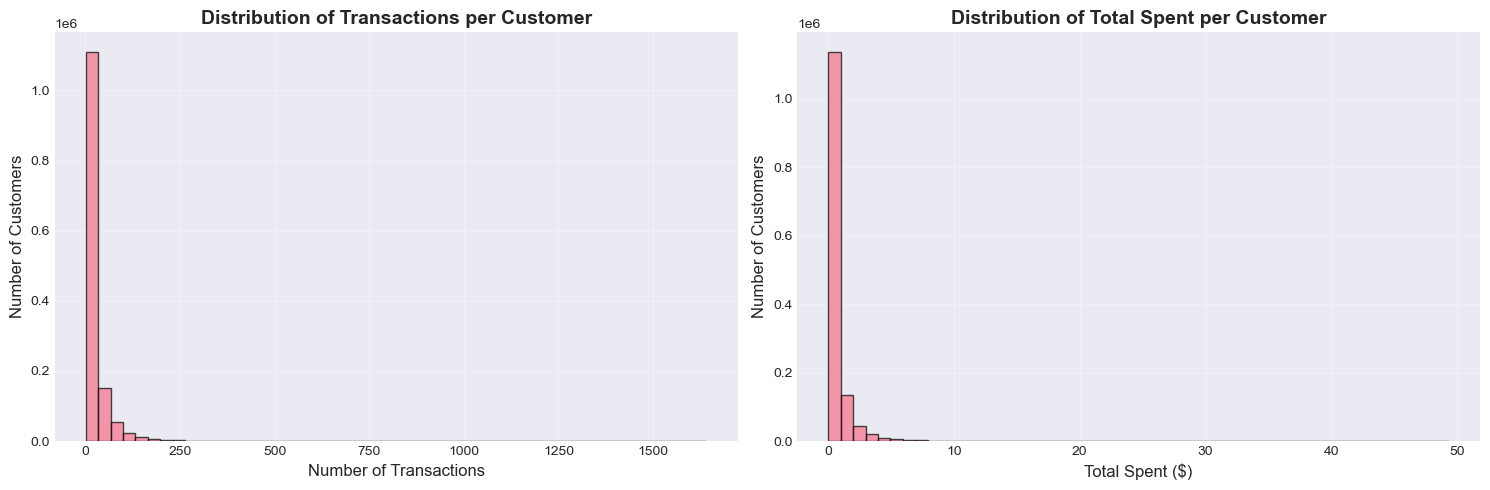


🔗 PRODUCT TRANSACTION ANALYSIS
--------------------------------------------------------------------------------

Article Transaction Statistics:


,article_id,purchase_count,avg_price,min_price,max_price
count,104547.000,104547.000,104547.000,104547.000,104547.000
mean,696820006.148,275.603,0.029,0.015,0.034
std,127717660.375,696.877,0.026,0.018,0.030
min,108775015.000,1.000,0.000,0.000,0.000
25%,616129004.500,13.000,0.014,0.006,0.017
50%,701050003.000,60.000,0.023,0.011,0.025
75%,794575013.500,262.000,0.034,0.019,0.042
max,956217002.000,42672.000,0.507,0.507,0.592



Top 10 Articles by Purchase Count:


,article_id,purchase_count,avg_price
53832,706016001,42672,0.032
53833,706016002,30862,0.032
1711,372860001,29337,0.013
24808,610776002,25234,0.008
70124,759871002,23799,0.006
1712,372860002,22472,0.012
3706,464297007,21782,0.016
2233,399223001,19604,0.031
58427,720125001,18975,0.032
24807,610776001,18777,0.008



Top 10 Articles with Details:


,article_id,purchase_count,avg_price,prod_name,product_type_name,department_name
0,706016001,42672,0.032,Jade HW Skinny Denim TRS,Trousers,Trousers
1,706016002,30862,0.032,Jade HW Skinny Denim TRS,Trousers,Trousers
2,372860001,29337,0.013,7p Basic Shaftless,Socks,Shopbasket Socks
3,610776002,25234,0.008,Tilly,T-shirt,Jersey Basic
4,759871002,23799,0.006,Tilda tank,Vest top,EQ Divided Basics
5,372860002,22472,0.012,7p Basic Shaftless,Socks,Shopbasket Socks
6,464297007,21782,0.016,Greta Thong Mynta Low 3p,Underwear bottom,Casual Lingerie
7,399223001,19604,0.031,Curvy Jeggings HW Ankle,Trousers,Denim Trousers
8,720125001,18975,0.032,SUPREME RW tights,Leggings/Tights,Ladies Sport Bottoms
9,610776001,18777,0.008,Tilly,T-shirt,Jersey Basic


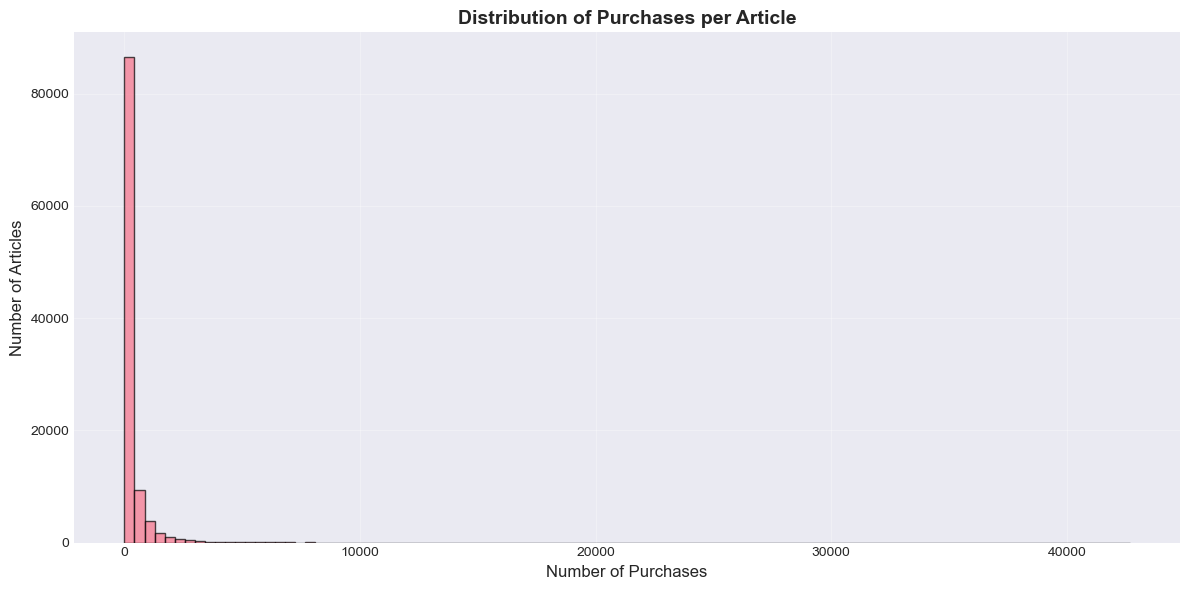


🔗 PRODUCT CATEGORY PERFORMANCE
--------------------------------------------------------------------------------

Top 15 Departments by Revenue:


,department,transaction_count,total_revenue
208,Trouser,1548971,53422.896
124,Knitwear,1502706,52373.031
195,Swimwear,2128005,47027.010
54,Dress,1008274,40748.589
33,Blouse,1518230,39058.746
81,Jersey,1390422,38611.859
151,Outwear,348026,28465.969
46,Denim Trousers,579885,25621.926
210,Trousers,715590,22450.625
87,Jersey fancy,1078516,21707.218


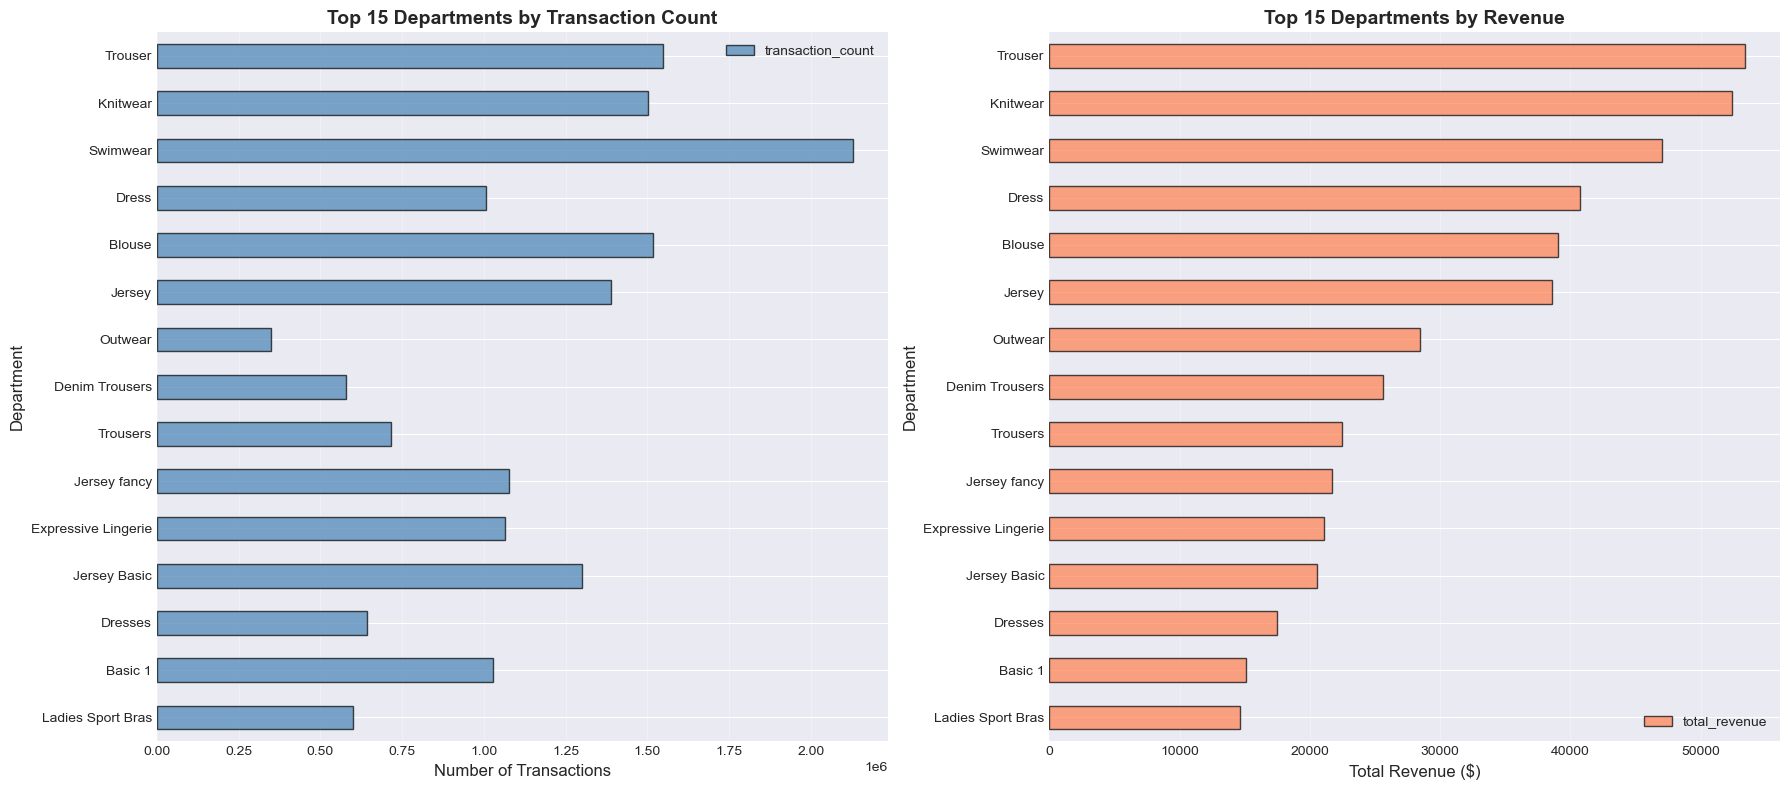


🔗 CUSTOMER DEMOGRAPHICS AND SPENDING
--------------------------------------------------------------------------------

Average Spending by Age Group:


,mean,median,count
18-25,0.472,0.195,408509
26-35,0.723,0.291,371844
36-45,0.596,0.208,167746
46-55,0.620,0.246,254998
56-65,0.535,0.196,121945
65+,0.366,0.125,37239


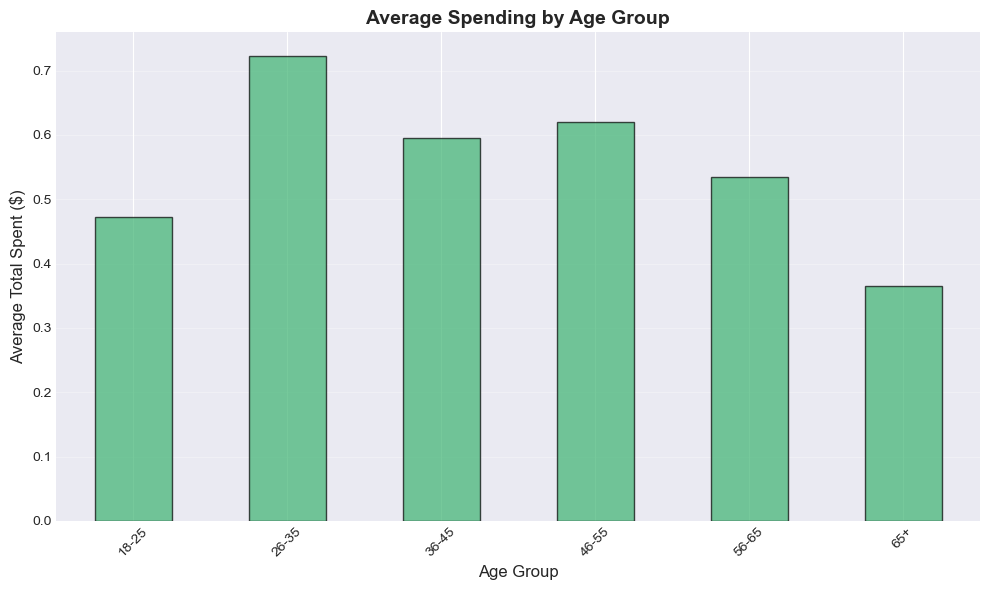


Average Spending by Club Membership Status:


,mean,median,count
club_member_status,,,
ACTIVE,0.617,0.246,1263183
LEFT CLUB,0.499,0.171,466
PRE-CREATE,0.189,0.102,92578
UNKNOWN,0.269,0.088,6054


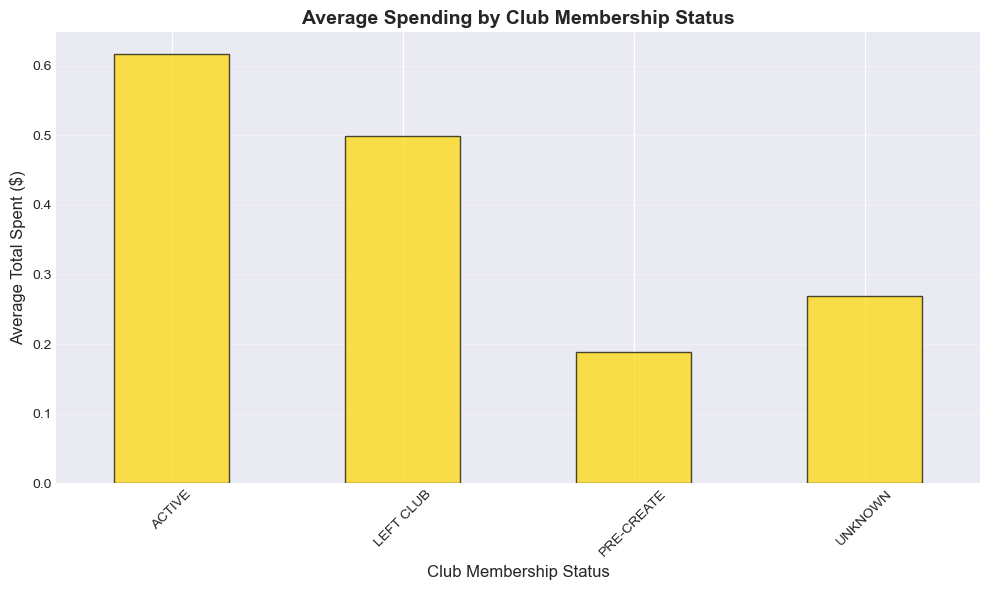


INTEGRATED ANALYSIS COMPLETE


In [ ]:
# INTEGRATED ANALYSIS
if transactions is not None and customers is not None and articles is not None:
    print("="*80)
    print("INTEGRATED ANALYSIS: CUSTOMER-TRANSACTION-PRODUCT RELATIONSHIPS")
    print("="*80)

    # Merge transactions with customer data
    print("\n🔗 CUSTOMER TRANSACTION ANALYSIS")
    print("-" * 80)

    # Customer transaction summary
    customer_trans_summary = transactions.groupby('customer_id').agg({
        'article_id': 'count',
        'price': ['sum', 'mean', 'min', 'max']
    }).reset_index()

    customer_trans_summary.columns = ['customer_id', 'transaction_count', 'total_spent', 'avg_transaction_value', 'min_transaction', 'max_transaction']

    print("\nCustomer Transaction Statistics:")
    display(customer_trans_summary.describe())

    # Top customers by transaction count
    top_customers_txns = customer_trans_summary.nlargest(10, 'transaction_count')[['customer_id', 'transaction_count', 'total_spent']]
    print("\nTop 10 Customers by Transaction Count:")
    display(top_customers_txns)

    # Top customers by total spent
    top_customers_spent = customer_trans_summary.nlargest(10, 'total_spent')[['customer_id', 'transaction_count', 'total_spent']]
    print("\nTop 10 Customers by Total Spent:")
    display(top_customers_spent)

    # Customer transaction distribution
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Transaction count distribution
    customer_trans_summary['transaction_count'].hist(bins=50, ax=axes[0], edgecolor='black', alpha=0.7)
    axes[0].set_title('Distribution of Transactions per Customer', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Number of Transactions', fontsize=12)
    axes[0].set_ylabel('Number of Customers', fontsize=12)
    axes[0].grid(True, alpha=0.3)

    # Total spent distribution
    customer_trans_summary['total_spent'].hist(bins=50, ax=axes[1], edgecolor='black', alpha=0.7)
    axes[1].set_title('Distribution of Total Spent per Customer', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Total Spent ($)', fontsize=12)
    axes[1].set_ylabel('Number of Customers', fontsize=12)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Merge transactions with article data
    print("\n🔗 PRODUCT TRANSACTION ANALYSIS")
    print("-" * 80)

    # Article transaction summary
    article_trans_summary = transactions.groupby('article_id').agg({
        'customer_id': 'count',
        'price': ['mean', 'min', 'max']
    }).reset_index()

    article_trans_summary.columns = ['article_id', 'purchase_count', 'avg_price', 'min_price', 'max_price']

    print("\nArticle Transaction Statistics:")
    display(article_trans_summary.describe())

    # Top articles by purchase count
    top_articles = article_trans_summary.nlargest(10, 'purchase_count')[['article_id', 'purchase_count', 'avg_price']]
    print("\nTop 10 Articles by Purchase Count:")
    display(top_articles)

    # Merge with article details
    top_articles_detailed = top_articles.merge(
        articles[['article_id', 'prod_name', 'product_type_name', 'department_name']],
        on='article_id',
        how='left'
    )
    print("\nTop 10 Articles with Details:")
    display(top_articles_detailed)

    # Article purchase distribution
    plt.figure(figsize=(12, 6))
    article_trans_summary['purchase_count'].hist(bins=100, edgecolor='black', alpha=0.7)
    plt.title('Distribution of Purchases per Article', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Purchases', fontsize=12)
    plt.ylabel('Number of Articles', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Product category analysis
    print("\n🔗 PRODUCT CATEGORY PERFORMANCE")
    print("-" * 80)

    # Merge transactions with articles to get category information
    trans_articles = transactions.merge(
        articles[['article_id', 'department_name', 'product_group_name', 'product_type_name']],
        on='article_id',
        how='left'
    )

    # Department performance
    if 'department_name' in trans_articles.columns:
        dept_performance = trans_articles.groupby('department_name').agg({
            'article_id': 'count',
            'price': 'sum'
        }).reset_index()
        dept_performance.columns = ['department', 'transaction_count', 'total_revenue']
        dept_performance = dept_performance.sort_values('total_revenue', ascending=False).head(15)

        print("\nTop 15 Departments by Revenue:")
        display(dept_performance)

        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(18, 8))

        dept_performance.plot(x='department', y='transaction_count', kind='barh', ax=axes[0],
                             color='steelblue', edgecolor='black', alpha=0.7)
        axes[0].set_title('Top 15 Departments by Transaction Count', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Number of Transactions', fontsize=12)
        axes[0].set_ylabel('Department', fontsize=12)
        axes[0].invert_yaxis()
        axes[0].grid(True, alpha=0.3, axis='x')

        dept_performance.plot(x='department', y='total_revenue', kind='barh', ax=axes[1],
                             color='coral', edgecolor='black', alpha=0.7)
        axes[1].set_title('Top 15 Departments by Revenue', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Total Revenue ($)', fontsize=12)
        axes[1].set_ylabel('Department', fontsize=12)
        axes[1].invert_yaxis()
        axes[1].grid(True, alpha=0.3, axis='x')

        plt.tight_layout()
        plt.show()

    # Customer demographics and spending
    if 'age' in customers.columns:
        print("\n🔗 CUSTOMER DEMOGRAPHICS AND SPENDING")
        print("-" * 80)

        # Merge customer transaction summary with customer demographics
        customer_analysis = customer_trans_summary.merge(
            customers[['customer_id', 'age', 'club_member_status', 'fashion_news_frequency']],
            on='customer_id',
            how='left'
        )

        # Age and spending relationship
        age_spending = customer_analysis.groupby(pd.cut(customer_analysis['age'], bins=[0, 25, 35, 45, 55, 65, 100]))['total_spent'].agg(['mean', 'median', 'count'])
        age_spending.index = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
        print("\nAverage Spending by Age Group:")
        display(age_spending)

        # Visualization
        plt.figure(figsize=(10, 6))
        age_spending['mean'].plot(kind='bar', color='mediumseagreen', edgecolor='black', alpha=0.7)
        plt.title('Average Spending by Age Group', fontsize=14, fontweight='bold')
        plt.xlabel('Age Group', fontsize=12)
        plt.ylabel('Average Total Spent ($)', fontsize=12)
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

        # Club membership and spending
        if 'club_member_status' in customer_analysis.columns:
            club_spending = customer_analysis.groupby('club_member_status')['total_spent'].agg(['mean', 'median', 'count'])
            print("\nAverage Spending by Club Membership Status:")
            display(club_spending)

            # Visualization
            plt.figure(figsize=(10, 6))
            club_spending['mean'].plot(kind='bar', color='gold', edgecolor='black', alpha=0.7)
            plt.title('Average Spending by Club Membership Status', fontsize=14, fontweight='bold')
            plt.xlabel('Club Membership Status', fontsize=12)
            plt.ylabel('Average Total Spent ($)', fontsize=12)
            plt.xticks(rotation=45)
            plt.grid(True, alpha=0.3, axis='y')
            plt.tight_layout()
            plt.show()

    print("\n" + "="*80)
    print("INTEGRATED ANALYSIS COMPLETE")
    print("="*80)

else:
    print("⚠ Cannot perform integrated analysis - missing required datasets")


In [ ]:
# KEY INSIGHTS AND SUMMARY
print("="*80)
print("KEY INSIGHTS AND SUMMARY")
print("="*80)

insights = []

# Dataset overview
if customers is not None:
    insights.append(f"📊 Customers: {len(customers):,} unique customers in the dataset")
    if 'age' in customers.columns:
        avg_age = customers['age'].mean()
        insights.append(f"   - Average customer age: {avg_age:.1f} years")
    if 'club_member_status' in customers.columns:
        active_members = (customers['club_member_status'] == 'ACTIVE').sum()
        active_pct = (active_members / len(customers) * 100)
        insights.append(f"   - Active club members: {active_pct:.1f}% of customers")

if articles is not None:
    insights.append(f"\n📦 Products: {len(articles):,} unique articles/products in the dataset")
    if 'department_name' in articles.columns:
        num_depts = articles['department_name'].nunique()
        insights.append(f"   - Number of departments: {num_depts}")
    if 'colour_group_name' in articles.columns:
        top_color = articles['colour_group_name'].value_counts().index[0]
        insights.append(f"   - Most common color: {top_color}")

if transactions is not None:
    insights.append(f"\n💰 Transactions: {len(transactions):,} total transactions")
    if 't_dat' in transactions.columns:
        date_range = f"{transactions['t_dat'].min().date()} to {transactions['t_dat'].max().date()}"
        insights.append(f"   - Date range: {date_range}")
    if 'price' in transactions.columns:
        total_revenue = transactions['price'].sum()
        avg_transaction = transactions['price'].mean()
        insights.append(f"   - Total revenue: ${total_revenue:,.2f}")
        insights.append(f"   - Average transaction value: ${avg_transaction:.2f}")

    # Customer engagement
    if 'customer_id' in transactions.columns:
        unique_customers = transactions['customer_id'].nunique()
        avg_txns_per_customer = len(transactions) / unique_customers
        insights.append(f"   - Active customers: {unique_customers:,}")
        insights.append(f"   - Average transactions per customer: {avg_txns_per_customer:.1f}")

# Print insights
for insight in insights:
    print(insight)

print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS COMPLETE")
print("="*80)
print("\nThis analysis provides a comprehensive overview of the H&M customer analytics data.")
print("The visualizations and statistics presented help understand:")
print("  • Customer demographics and characteristics")
print("  • Product catalog composition and categories")
print("  • Transaction patterns and sales trends")
print("  • Relationships between customers, products, and transactions")
print("\nThese insights can inform further analytical modeling and business decisions.")


KEY INSIGHTS AND SUMMARY
📊 Customers: 1,371,980 unique customers in the dataset
   - Average customer age: 36.3 years
   - Active club members: 92.7% of customers

📦 Products: 105,421 unique articles/products in the dataset
   - Number of departments: 250
   - Most common color: Black

💰 Transactions: 28,813,419 total transactions
   - Date range: 2018-09-20 to 2020-09-22
   - Total revenue: $798,958.07
   - Average transaction value: $0.03
   - Active customers: 1,362,281
   - Average transactions per customer: 21.2

EXPLORATORY DATA ANALYSIS COMPLETE

This analysis provides a comprehensive overview of the H&M customer analytics data.
The visualizations and statistics presented help understand:
  • Customer demographics and characteristics
  • Product catalog composition and categories
  • Transaction patterns and sales trends
  • Relationships between customers, products, and transactions

These insights can inform further analytical modeling and business decisions.
